<a href="https://colab.research.google.com/github/fxrdhan/ML_scikit-learn_Cookbook_O-Reilly/blob/main/Chapter_03_Dimensionality_Reduction_Techniques/Chapter_03_Dimensionality_Reduction_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3 — Dimensionality Reduction Techniques

| | |
|---|---|
| **Book** | *scikit-learn Cookbook, Third Edition* — John Sukup (Packt Publishing, 2025) |
| **Library version targeted by the book** | scikit-learn 1.5 |
| **Version used to run this notebook** | scikit-learn 1.9.1 on Python 3.12 (printed by the setup cell) |
| **What this notebook contains** | reproduction of every code listing in the chapter and of the official exercise solutions, chapter and recipe summaries, theoretical deep-dives, and extra experiments |

## Chapter overview

The book opens with a kitchen analogy: improvise with the ingredients of a soup recipe and you can ruin the soup. In machine learning the ingredients are the training features, and the right combination matters for both training and performance. Chapter 3 is about finding that combination by **reducing the number of dimensions** while keeping the information that matters. It shows how to:

* understand **why** dimensionality reduction helps — simpler data, lower computational cost, less overfitting, and pictures of data that live in many dimensions — and its two families, **feature selection** and **feature extraction**;
* project data onto the directions of maximum variance with **principal component analysis (PCA)**;
* project labelled data onto the directions that best separate the classes with **linear discriminant analysis (LDA)**;
* draw high-dimensional data in two dimensions with **t-distributed stochastic neighbor embedding (t-SNE)**;
* **choose** between the techniques and weigh their **impact on model performance**;
* practise with two exercises: PCA before a logistic regression, and a t-SNE map next to K-means clusters.

### Recipes in this chapter

| # | Recipe | Code in the book | What this notebook adds |
|---|---|---|---|
| 1 | Introduction to dimensionality reduction | No | The curse of dimensionality measured: distances concentrate as dimensions grow |
| 2 | Transforming datasets with PCA | Yes, 3 listings + 1 in the repository | PCA derived by hand, what the book's arrows really show, why scaling matters, how many components to keep, PCA as compression |
| 3 | Maximizing class separability with LDA | Yes, 2 listings | Fisher's criterion by hand, why LDA does not need scaling, how a supervised projection can fool you |
| 4 | t-SNE and data visualization | Yes, 2 listings | How t-SNE turns distances into probabilities, the perplexity setting, neighbourhood preservation measured, what a t-SNE map cannot tell you |
| 5 | Selecting the right technique | No (a flowchart and a table) | Cost and quality of each technique measured, PCA followed by t-SNE |
| 6 | Impact on model performance | No | Accuracy against the number of components, and a dataset where high variance is not useful |
| 7 | Practical exercises in dimensionality reduction | Official solutions | Exercise 1 on Iris (as the text says) and on the digits (as the solution does), cross-validation, the adjusted Rand index for exercise 2 |

### How to read this notebook

Every recipe has the same structure:

1. **Summary** — what the book says, condensed.
2. **Theory** — the ideas behind it: math, algorithms and design reasoning.
3. **Book code** — the listing reproduced from the book (page numbers refer to the printed edition), followed by an **output analysis**.
4. **Extra** — experiments written for this notebook to make the theory concrete. They are *not* part of the book.

Every code cell starts with a label comment: `# BOOK CODE` for a listing reproduced from the book, `# EXTRA` for code written for this notebook.

---
## 0. Setup

Every dataset in this chapter ships with scikit-learn (`load_wine`, `load_digits`, `load_iris`) or is generated with a fixed seed, so the notebook runs offline. The setup cell prints the library versions, fixes a global seed and defines the plotting style used by the extra figures (the book's own listings keep their original colours).

In [1]:
import platform
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from matplotlib import patheffects

print(f"Python       : {platform.python_version()}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"NumPy        : {np.__version__}")
print(f"pandas       : {pd.__version__}")
print(f"Matplotlib   : {matplotlib.__version__}")

sk_version = tuple(int(part) for part in sklearn.__version__.split(".")[:2])
assert sk_version >= (1, 5), "This notebook needs scikit-learn >= 1.5 -> pip install -U scikit-learn"

np.random.seed(0)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

# A quiet, colour-blind-safe style used by the extra figures in this notebook
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a"]  # blue, orange, aqua (checked for colour-vision deficiency)
INK, INK_SOFT, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.titlecolor": INK, "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": INK_SOFT, "axes.labelsize": 10,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK_SOFT, "ytick.labelcolor": INK_SOFT,
    "axes.prop_cycle": plt.cycler(color=PALETTE),
    "lines.linewidth": 2, "legend.frameon": False, "legend.labelcolor": INK_SOFT,
    "figure.dpi": 110, "font.size": 10,
})


def label_groups(ax, embedding, labels):
    """Write each class label at the median of its points, so identity is carried by text, not by colour."""
    for lab in np.unique(labels):
        x, y = np.median(embedding[labels == lab], axis=0)
        ax.text(x, y, str(lab), fontsize=12, fontweight="bold", color=INK, ha="center", va="center",
                path_effects=[patheffects.withStroke(linewidth=3, foreground=SURFACE)])

Python       : 3.12.3
scikit-learn : 1.9.1
NumPy        : 2.5.3
pandas       : 3.0.6
Matplotlib   : 3.11.2


---
## 1. Introduction to dimensionality reduction

### Summary

* Dimensionality reduction is as fundamental to a robust pipeline as the preprocessing of Chapter 2. It **reduces the number of features while keeping as much relevant information as possible**. Feeding every available column to a model adds garbage, not information ("garbage in, garbage out").
* The book gives four reasons why it is essential:
  * **Simplifying data** — fewer features are easier to analyse and interpret.
  * **Reducing computational cost** — faster training and lower resource use.
  * **Improving model performance** — high-dimensional data invite overfitting; removing irrelevant or redundant features helps the model generalise.
  * **Enhancing visualization** — we can only see two or three dimensions.
* The techniques fall into two families:
  * **Feature selection** keeps a subset of the original features without transforming them:
    * *filter* methods use statistics such as the correlation with the target;
    * *wrapper* methods search over subsets by training a model, as recursive feature elimination does;
    * *embedded* methods select while training, as the Lasso does;
    * *hybrid* methods combine them.
  * **Feature extraction** builds a smaller set of new features from the original ones:
    * **PCA** keeps the directions of maximum variance;
    * **LDA** maximizes class separability using the labels;
    * **t-SNE** is mainly for visualization and preserves local structure.
* A four-step workflow:
  1. assess the dimensionality of the data and its problems;
  2. choose selection or extraction;
  3. apply the method with scikit-learn;
  4. train models on the original and the reduced data, and compare them.

> The book gives no code for this recipe. The extra below measures the problem that motivates the whole chapter.

### Theory: the curse of dimensionality

High-dimensional spaces behave very differently from the two- and three-dimensional spaces our intuition is built on.

* **Space grows exponentially.** A grid with 10 cells per axis has $10^p$ cells in $p$ dimensions. A fixed number of samples therefore covers a vanishing fraction of the space, and every point is far from the others.
* **Neighbourhoods stop being local.** To capture a fraction $r$ of uniformly distributed data, a sub-cube needs an edge of $r^{1/p}$ times the range of each feature. For $r = 1\%$ that is 10% of each range when $p = 2$, but 63% when $p = 10$ (Hastie et al., 2009, §2.5). A "nearest neighbour" then is not near at all.
* **Distances concentrate.** For points with independent coordinates, the relative gap between the farthest and the nearest neighbour vanishes as the dimension grows (Beyer et al., 1999):

$$\frac{D_{\max} - D_{\min}}{D_{\min}} \;\longrightarrow\; 0 \quad \text{as } p \to \infty .$$

  The standard deviation of pairwise distances grows more slowly than their mean, roughly like $1/\sqrt{p}$ relative to it. Methods built on distances (k-NN, K-means, kernels) lose their ability to tell near from far.
* **Why reduction works anyway.** Real data rarely fill all their dimensions. Features are correlated, and the points lie close to a subspace or a curved manifold of much lower *intrinsic* dimension. PCA and LDA look for a low-dimensional linear subspace; t-SNE looks for the local neighbourhood structure of a curved one.

**Feature selection or feature extraction?**

| | Feature selection | Feature extraction |
|---|---|---|
| Output | a subset of the original columns | new columns, each a combination of many original ones |
| Interpretability | high: every kept column keeps its meaning | lower: a new feature mixes many original ones |
| scikit-learn tools | `SelectKBest`, `RFE`, `SelectFromModel` (Chapter 2) | `PCA`, `LinearDiscriminantAnalysis`, `TSNE`, `KernelPCA`, `TruncatedSVD` |
| Uses the labels? | filters and wrappers usually do | PCA and t-SNE do not; LDA does |

,nearest pair,farthest pair,relative contrast (max - min) / min,std / mean
dimensions,,,,
2,0.003,1.358,533.858,0.476
10,0.405,2.212,4.461,0.194
100,3.037,4.927,0.622,0.060
1000,11.955,13.823,0.156,0.019
10000,39.896,41.781,0.047,0.006


edge of a sub-cube holding 1% of uniform data (fraction of each feature's range): {1: 0.01, 2: 0.1, 10: 0.631, 100: 0.955}


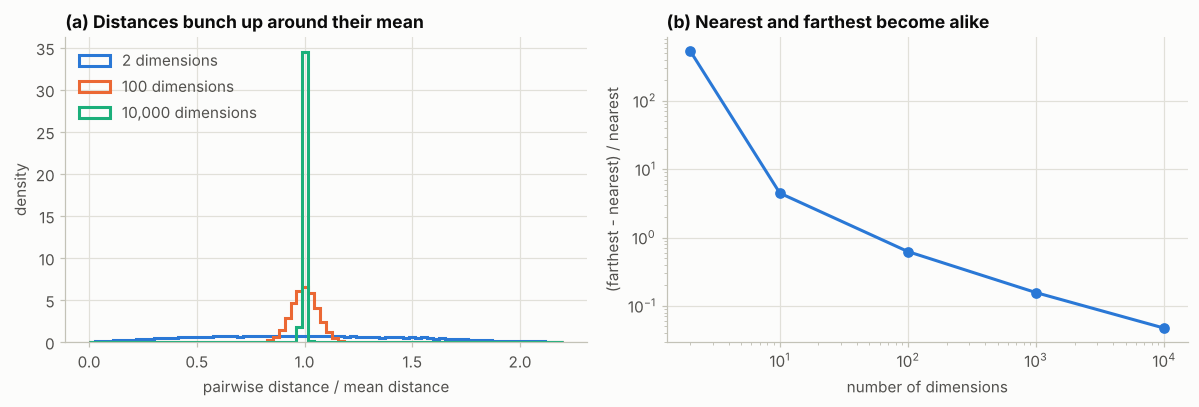

In [2]:
# EXTRA: The curse of dimensionality -- pairwise distances concentrate as the dimension grows
from scipy.spatial.distance import pdist

rng = np.random.default_rng(0)
dims = [2, 10, 100, 1000, 10000]
rows, scaled_distances = [], {}
for p in dims:
    points = rng.uniform(size=(200, p))      # 200 points spread uniformly in the unit hypercube
    dist = pdist(points)                     # all 19,900 pairwise Euclidean distances
    rows.append((p, dist.min(), dist.max(), (dist.max() - dist.min()) / dist.min(), dist.std() / dist.mean()))
    scaled_distances[p] = dist / dist.mean()
concentration = pd.DataFrame(rows, columns=["dimensions", "nearest pair", "farthest pair",
                                            "relative contrast (max - min) / min", "std / mean"]).set_index("dimensions")
display(concentration.round(3))
print("edge of a sub-cube holding 1% of uniform data (fraction of each feature's range):",
      {p: round(0.01 ** (1 / p), 3) for p in [1, 2, 10, 100]})

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ax = axes[0]
for color, p in zip(PALETTE, [2, 100, 10000]):
    ax.hist(scaled_distances[p], bins=80, range=(0, 2.2), density=True, histtype="step", linewidth=2,
            color=color, label=f"{p:,} dimensions")
ax.set(xlabel="pairwise distance / mean distance", ylabel="density",
       title="(a) Distances bunch up around their mean")
ax.legend(loc="upper left")
ax = axes[1]
ax.plot(concentration.index, concentration.iloc[:, 2], color=PALETTE[0], marker="o", markersize=6)
ax.set(xscale="log", yscale="log", xlabel="number of dimensions",
       ylabel="(farthest - nearest) / nearest", title="(b) Nearest and farthest become alike")
plt.tight_layout()
plt.show()

**Output analysis.**

* In 2 dimensions the farthest pair of points is several hundred times farther apart than the nearest pair. In 10,000 dimensions it is only about 5% farther: every point is roughly equally far from every other one.
* The ratio of the spread of the distances to their mean drops from about 0.5 to about 0.006, close to the $1/\sqrt{p}$ rate. Each time the dimension grows 100-fold, the ratio shrinks about 10-fold.
* The cube that holds 1% of uniform data spans 63% of every feature's range in 10 dimensions and more than 95% in 100 dimensions.
* These are the conditions in which distance-based models degrade. The irrelevant features of Chapter 2 cost k-NN accuracy for the same reason. Removing the dimensions that carry no information restores the contrast between near and far.

---
## 2. Transforming datasets with PCA

### Summary

* PCA is one of the most widely used techniques for dimensionality reduction. It moves the data into a new coordinate system whose first axes — the **principal components** — capture the greatest variance in the data.
* **Getting ready:**
  * The recipe loads the wine dataset: 178 wines, 13 chemical measurements and 3 cultivars as classes.
  * The book notes that scikit-learn 1.5 ships six such toy datasets.
  * The data should be **standardized** before PCA, and the target must be **kept out** of it.
* **How to do it:**
  * A `Pipeline` chains `StandardScaler()` and `PCA(n_components=2)`. Pipelines become a convention for the rest of the book.
  * The wines are plotted on the two components, one marker per class.
  * An arrow for each component is drawn, scaled by 3 and labelled with its share of the variance.
  * Even at a glance, the classes separate on the two components (Figure 3.2).
* **How it works** — PCA proceeds in five steps:
  1. standardization;
  2. the covariance matrix;
  3. eigenvalues (the variance captured) and eigenvectors (the directions);
  4. choosing the components with the largest eigenvalues;
  5. projecting the data onto them.

  A bar chart shows that the two components explain **55.41%** of the variance (Figure 3.3).
* A 2×2 figure, whose code is only in the repository, shows two pairs of standardized features before and after PCA (Figure 3.4).
* **Hands-on exercises:** understand the dimensionality, scale the features, apply `PCA`, examine the explained variance and the transformed data, then use the reduced features in a model.

### Theory: PCA as variance maximization

Let $\mathbf{X}$ be the centred (here also standardized) $n \times p$ data matrix and $\mathbf{S} = \frac{1}{n-1}\mathbf{X}^\top\mathbf{X}$ its covariance matrix.

**The first component** is the unit vector along which the projected data vary most:

$$\mathbf{w}_1 = \arg\max_{\lVert \mathbf{w} \rVert = 1} \operatorname{Var}(\mathbf{X}\mathbf{w}) = \arg\max_{\lVert \mathbf{w} \rVert = 1} \mathbf{w}^\top \mathbf{S}\,\mathbf{w}.$$

Setting the gradient of the Lagrangian $\mathbf{w}^\top\mathbf{S}\mathbf{w} - \lambda(\mathbf{w}^\top\mathbf{w} - 1)$ to zero gives $\mathbf{S}\mathbf{w} = \lambda\mathbf{w}$. So $\mathbf{w}_1$ is an **eigenvector** of $\mathbf{S}$, and the variance it captures is $\mathbf{w}^\top\mathbf{S}\mathbf{w} = \lambda$, the **eigenvalue**: the best choice is the eigenvector with the largest eigenvalue. The $k$-th component is the eigenvector of the $k$-th largest eigenvalue. Because $\mathbf{S}$ is symmetric, the components are orthogonal, and the projected features are uncorrelated.

**Quantities scikit-learn reports:**

| Attribute | Meaning |
|---|---|
| `components_` | the eigenvectors, one per row (the *loadings* of the features) |
| `explained_variance_` | the eigenvalues $\lambda_k$ |
| `explained_variance_ratio_` | $\lambda_k / \sum_j \lambda_j$, the share of the total variance |
| `transform(X)` | the *scores* $\mathbf{X}\mathbf{W}_k$, the coordinates on the first $k$ components |
| `inverse_transform(Z)` | the reconstruction $\mathbf{Z}\mathbf{W}_k^\top$ (plus the mean) |

For standardized data, $\sum_j \lambda_j = p$, the trace of the correlation matrix. (scikit-learn's eigenvalues add up to $p\,n/(n-1)$, because `StandardScaler` divides by $n$ and the covariance by $n - 1$.) An eigenvalue above 1 means "more variance than one original feature", which is *Kaiser's rule* for choosing components.

**The SVD view.** Writing $\mathbf{X} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^\top$, the rows of $\mathbf{V}^\top$ are the components, $\lambda_k = \sigma_k^2/(n-1)$, and the scores are $\mathbf{U}_k\boldsymbol{\Sigma}_k$. scikit-learn computes PCA with an SVD, or, since version 1.5, with an eigendecomposition of the covariance matrix when there are many more samples than features (`svd_solver="covariance_eigh"`).

**The compression view.** Among all projections onto $k$ dimensions, PCA gives the smallest squared reconstruction error (Eckart–Young theorem). The squared error left over equals $(n-1)$ times the sum of the discarded eigenvalues. Keeping variance and losing as little information as possible are the same goal.

**Practical consequences:**

* **Scaling.** PCA maximizes variance in the units of the features, so a feature measured in large units dominates. Standardizing first is the same as running PCA on the correlation matrix.
* **Signs are arbitrary.** If $\mathbf{w}$ is an eigenvector, so is $-\mathbf{w}$. Another solver or library version may mirror a component without changing anything else.
* **Choosing $k$.** Common rules:
  * a scree plot, looking for the "elbow";
  * a cumulative-variance threshold such as 95% (`PCA(n_components=0.95)`);
  * Kaiser's rule;
  * best of all, cross-validating the downstream model (recipe 6).
* **Limits.** PCA is linear and unsupervised: high variance is not the same as relevance to the target (recipe 6 shows a counterexample). It is also sensitive to outliers, which inflate the variance.

In [3]:
# BOOK CODE: Transforming datasets with PCA -- getting ready (p. 48)
# Load libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
import warnings

# Set random seed for reproducibility and suppress warnings
np.random.seed(2024)
warnings.simplefilter(action='ignore', category=FutureWarning)

#Load dataset
wine = load_wine()
df_wine = pd.DataFrame(data=wine.data, columns=wine.feature_names)
target_wine = wine.target
display(df_wine.head(10))

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0


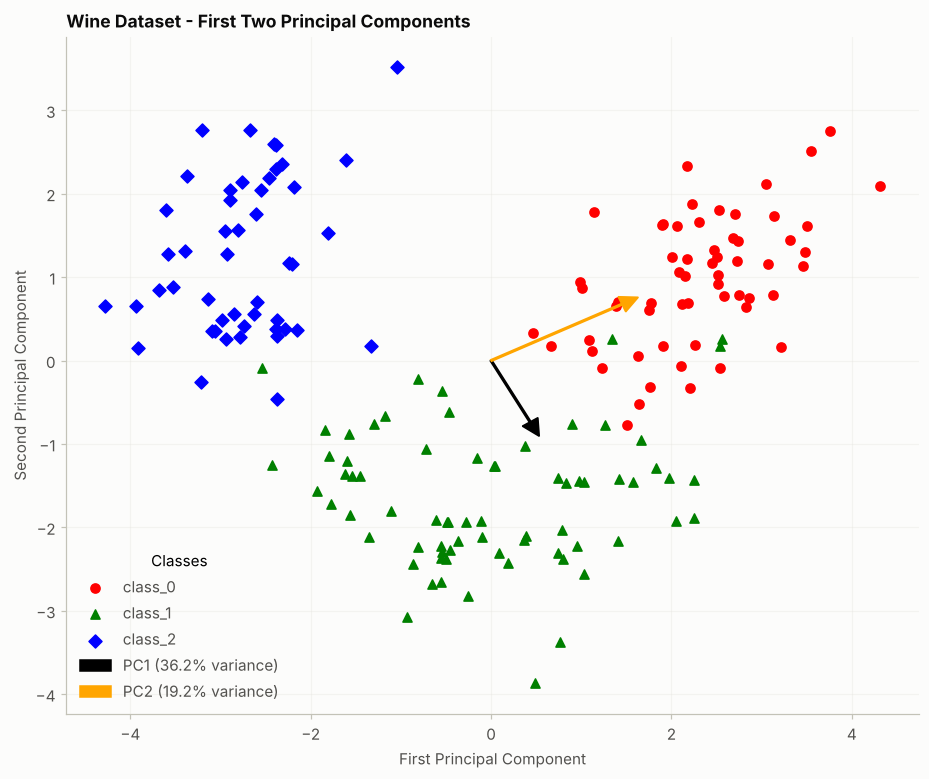

In [4]:
# BOOK CODE: Transforming datasets with PCA -- how to do it (pp. 49-50)
# Load libraries
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Create a pipeline for PCA
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Always scale before PCA
    ('pca', PCA(n_components=2))   # Reduce to 2 dimensions
])

# Fit and transform the data
X_pca = pca_pipeline.fit_transform(df_wine)

# Visualize the transformed data
plt.figure(figsize=(10, 8))
shapes = ['o', '^', 'D']
colors = ['r', 'g', 'b']

# Plot the scatter points
for i, (shape, color) in enumerate(zip(shapes, colors)):
    plt.scatter(X_pca[target_wine == i, 0], X_pca[target_wine == i, 1],
                c=color, marker=shape, label=wine.target_names[i])

# Get the PCA components and plot as vectors
pca = pca_pipeline.named_steps['pca']
origin = np.zeros(2)  # Origin point for vectors
arrow_colors = ['black', 'orange']

# Scale the components by their explained variance ratio for better visualization
scaling = 3
for i, (component, ratio) in enumerate(zip(pca.components_, pca.explained_variance_ratio_)):
    plt.arrow(origin[0], origin[1],
              component[0] * scaling, component[1] * scaling,
              color=arrow_colors[i],
              width=0.02, head_width=0.2, head_length=0.2,
              label=f'PC{i+1} ({ratio:.1%} variance)')

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Wine Dataset - First Two Principal Components')
plt.legend(title="Classes")
plt.grid(True, alpha=0.3)
plt.show()

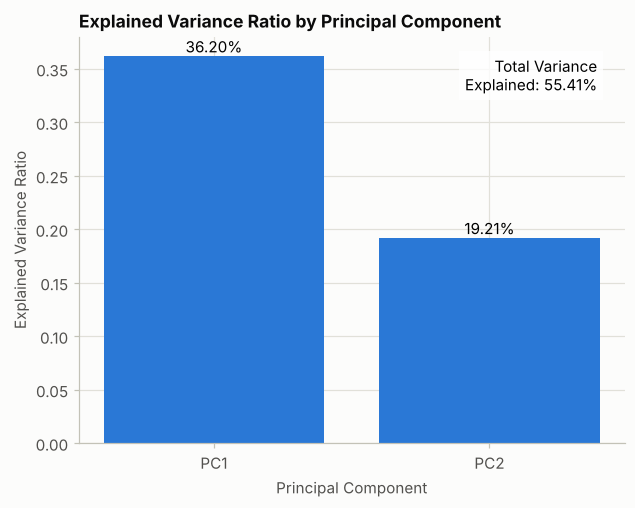

In [5]:
# BOOK CODE: Transforming datasets with PCA -- how it works, explained variance (pp. 52-53)
# Get the explained variance ratio
pca = pca_pipeline.named_steps['pca']
explained_variance_ratio = pca.explained_variance_ratio_

# Calculate cumulative variance
cumulative_variance = np.sum(explained_variance_ratio)

# Plot barchart
fig, ax = plt.subplots()

x = np.arange(1, len(explained_variance_ratio) + 1)
y = explained_variance_ratio
bars = ax.bar(x, y)

# Add percentage labels on bars
for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.2%}',
                        ha='center', va='bottom')

# Add cumulative variance text in upper right
ax.text(0.95, 0.95, f'Total Variance\nExplained: {cumulative_variance:.2%}',
                transform=ax.transAxes,
                ha='right', va='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Set custom x-axis labels for the two principal components
ax.set_xticks(x)
ax.set_xticklabels(['PC1', 'PC2'])

ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

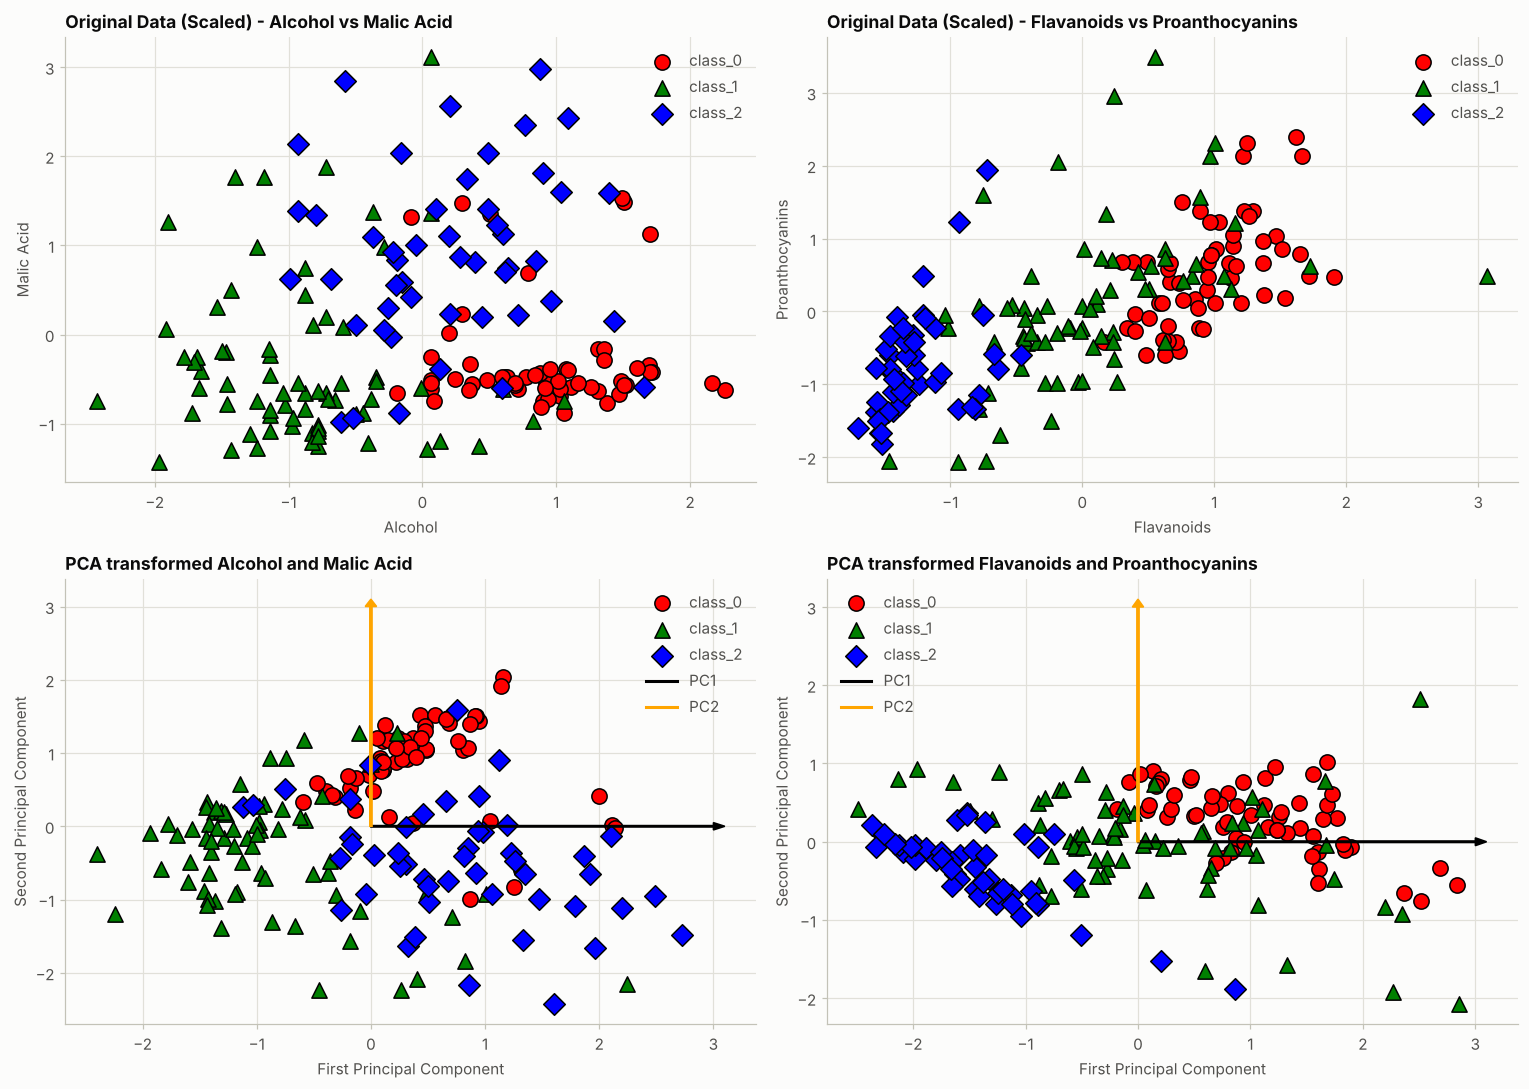

In [6]:
# BOOK CODE: Figure 3.4 -- PCA applied to two features (p. 54; the book prints only the figure,
# this code comes from the chapter's notebook in the official repository)
# Choose two features: 'alcohol' and 'malic_acid'
features_1 = ['alcohol', 'malic_acid']
df_wine_subset_1 = df_wine[features_1]
df_wine_subset_1 = pd.DataFrame(StandardScaler().fit_transform(df_wine_subset_1), columns=features_1)

# Perform PCA on the two features
pca_2d_1 = PCA(n_components=2)
X_pca_2d_1 = pca_2d_1.fit_transform(df_wine_subset_1)

# Choose two different features: 'flavanoids' and 'proanthocyanins'
features_2 = ['flavanoids', 'proanthocyanins']
df_wine_subset_2 = df_wine[features_2]
df_wine_subset_2 = pd.DataFrame(StandardScaler().fit_transform(df_wine_subset_2), columns=features_2)

# Perform PCA on the two different features
pca_2d_2 = PCA(n_components=2)
X_pca_2d_2 = pca_2d_2.fit_transform(df_wine_subset_2)

# Create a figure with four subplots in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original data plot 1 (top left)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = target_wine == i
    axes[0,0].scatter(df_wine_subset_1['alcohol'][mask],
                     df_wine_subset_1['malic_acid'][mask],
                     marker=shape, c=color, edgecolor='k', s=100,
                     label=wine.target_names[i])
axes[0,0].set_xlabel('Alcohol')
axes[0,0].set_ylabel('Malic Acid')
axes[0,0].set_title('Original Data (Scaled) - Alcohol vs Malic Acid')
axes[0,0].legend()

# Original data plot 2 (top right)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = target_wine == i
    axes[0,1].scatter(df_wine_subset_2['flavanoids'][mask],
                     df_wine_subset_2['proanthocyanins'][mask],
                     marker=shape, c=color, edgecolor='k', s=100,
                     label=wine.target_names[i])
axes[0,1].set_xlabel('Flavanoids')
axes[0,1].set_ylabel('Proanthocyanins')
axes[0,1].set_title('Original Data (Scaled) - Flavanoids vs Proanthocyanins')
axes[0,1].legend()

# PCA plot 1 (bottom left)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = target_wine == i
    axes[1,0].scatter(X_pca_2d_1[mask, 0],
                     X_pca_2d_1[mask, 1],
                     marker=shape, c=color, edgecolor='k', s=100,
                     label=wine.target_names[i])
axes[1,0].set_xlabel('First Principal Component')
axes[1,0].set_ylabel('Second Principal Component')
axes[1,0].set_title('PCA transformed Alcohol and Malic Acid')

# Plot the principal components as vectors for the first PCA plot
origin_1 = np.zeros(2)
components_1 = np.eye(2)
arrow_colors_1 = ['black', 'orange']
scaling = 3
for i, component in enumerate(components_1):
    axes[1,0].arrow(origin_1[0], origin_1[1], component[0] * scaling, component[1] * scaling,
                    color=arrow_colors_1[i], width=0.02, head_width=0.1, head_length=0.1)
    axes[1,0].plot([], [], color=arrow_colors_1[i], label=f'PC{i+1}')

axes[1,0].legend()

# PCA plot 2 (bottom right)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = target_wine == i
    axes[1,1].scatter(X_pca_2d_2[mask, 0],
                     X_pca_2d_2[mask, 1],
                     marker=shape, c=color, edgecolor='k', s=100,
                     label=wine.target_names[i])
axes[1,1].set_xlabel('First Principal Component')
axes[1,1].set_ylabel('Second Principal Component')
axes[1,1].set_title('PCA transformed Flavanoids and Proanthocyanins')

# Plot the principal components as vectors for the second PCA plot
origin_2 = np.zeros(2)
components_2 = np.eye(2)
for i, component in enumerate(components_2):
    axes[1,1].arrow(origin_2[0], origin_2[1], component[0] * scaling, component[1] * scaling,
                    color=arrow_colors_1[i], width=0.02, head_width=0.1, head_length=0.1)
    axes[1,1].plot([], [], color=arrow_colors_1[i], label=f'PC{i+1}')

axes[1,1].legend()

plt.tight_layout()
plt.show()

**Output analysis.**

* **The data.** The 13 features live on very different scales: hue is around 1, magnesium around 100 and proline in the hundreds to over a thousand. This is why the book standardizes before PCA; extra (c) shows what happens without it.
* **The scatter plot.** On the first two components the three cultivars form three groups that overlap only at their edges, without PCA ever seeing the labels. PC1 separates class_0 from class_2, and PC2 sets class_1 apart from both.
* **The explained variance.** PC1 explains 36.20% and PC2 19.21%, together **55.41%** — exactly the value printed in the book's Figure 3.3. The book's remark that "the first two principal components capture the most variation" should be read as "more than any other two directions": 45% of the variance is still outside this plane.
* **What the arrows show.** The listing draws `component[0]` and `component[1]` — the first two entries of each 13-dimensional component. Those are the weights of **alcohol** and **malic acid** on PC1 and PC2, not the direction of the components. In this plot PC1 *is* the horizontal axis and PC2 the vertical one. Only the labels, with each component's share of the variance, describe the components themselves. Extra (b) draws a proper biplot with the loadings of all 13 features.
* **Figure 3.4.** For two standardized features, PCA with two components can only **rotate** the cloud: the correlation matrix $\begin{pmatrix} 1 & r \\ r & 1 \end{pmatrix}$ always has the eigenvectors $(1, 1)/\sqrt{2}$ and $(1, -1)/\sqrt{2}$. The bottom row is the top row turned by 45° (and possibly mirrored), and the arrows (`np.eye(2)`) are simply the new axes. A rotation keeps every distance, so it cannot "better separate the wine classes", as the caption suggests. Extra (b) checks this numerically.

In [7]:
# EXTRA: (a) PCA by hand -- eigenvectors of the covariance matrix, and the SVD, versus sklearn's PCA
Z = StandardScaler().fit_transform(df_wine)                     # standardized data: mean 0, std 1
S = np.cov(Z, rowvar=False)                                      # 13 x 13 covariance (= correlation) matrix
eigvals, eigvecs = np.linalg.eigh(S)                             # eigh: symmetric matrix, ascending order
order = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[order], eigvecs[:, order]

U, sing, Vt = np.linalg.svd(Z, full_matrices=False)              # SVD of the data matrix itself
pca_full = PCA().fit(Z)                                          # all 13 components

print("eigenvalues of S (largest 4)    :", eigvals[:4].round(4))
print("singular values^2 / (n - 1)     :", (sing[:4] ** 2 / (len(Z) - 1)).round(4))
print("sklearn explained_variance_     :", pca_full.explained_variance_[:4].round(4))
print("sum of all eigenvalues          :", round(eigvals.sum(), 4),
      f"(= 13 x n/(n-1) = {13 * len(Z) / (len(Z) - 1):.4f}: StandardScaler divides by n, the covariance by n - 1)")
print("explained variance ratio PC1-PC2:", (eigvals[:2] / eigvals.sum()).round(4))
print("same directions as components_ (up to sign):", np.allclose(np.abs(eigvecs[:, :2].T), np.abs(pca_full.components_[:2])))
print("same scores as the book's X_pca (up to sign):", np.allclose(np.abs(Z @ eigvecs[:, :2]), np.abs(X_pca)))
print("components are orthonormal (W W^T = I)     :", np.allclose(pca_full.components_ @ pca_full.components_.T, np.eye(13)))
print("scores are uncorrelated (largest |corr|)   :", f"{np.abs(np.corrcoef(pca_full.transform(Z), rowvar=False) - np.eye(13)).max():.1e}")

eigenvalues of S (largest 4)    : [4.7324 2.5111 1.4542 0.9242]
singular values^2 / (n - 1)     : [4.7324 2.5111 1.4542 0.9242]
sklearn explained_variance_     : [4.7324 2.5111 1.4542 0.9242]
sum of all eigenvalues          : 13.0734 (= 13 x n/(n-1) = 13.0734: StandardScaler divides by n, the covariance by n - 1)
explained variance ratio PC1-PC2: [0.362  0.1921]
same directions as components_ (up to sign): True
same scores as the book's X_pca (up to sign): True
components are orthonormal (W W^T = I)     : True
scores are uncorrelated (largest |corr|)   : 1.3e-15


what the book's arrows plot (entries 0 and 1 of each component = alcohol and malic_acid):
              PC1    PC2
alcohol     0.144  0.484
malic_acid -0.245  0.225
largest |weights| on PC1: ['flavanoids', 'total_phenols', 'od280/od315_of_diluted_wines']
largest |weights| on PC2: ['color_intensity', 'alcohol', 'proline']

components for alcohol + malic_acid:
 [[ 0.7071  0.7071]
 [ 0.7071 -0.7071]]
largest change of any pairwise distance after this PCA: 1.3e-15


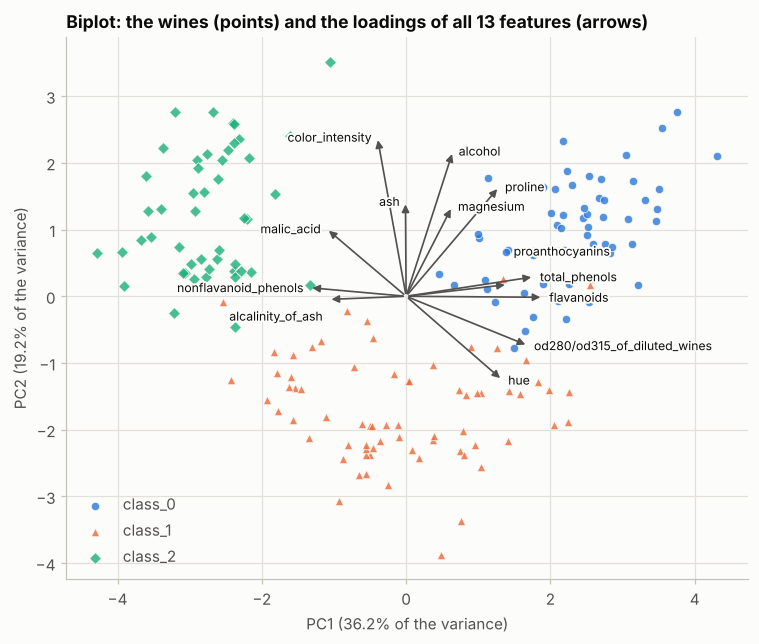

In [8]:
# EXTRA: (b) What the arrows should show -- a biplot with all 13 loadings; and PCA on two features is a rotation
loadings = pd.DataFrame(pca.components_.T, index=wine.feature_names, columns=["PC1", "PC2"])
print("what the book's arrows plot (entries 0 and 1 of each component = alcohol and malic_acid):")
print(loadings.iloc[:2].round(3).to_string())
print("largest |weights| on PC1:", loadings["PC1"].abs().sort_values(ascending=False).index[:3].tolist())
print("largest |weights| on PC2:", loadings["PC2"].abs().sort_values(ascending=False).index[:3].tolist())

pair = StandardScaler().fit_transform(df_wine[["alcohol", "malic_acid"]])
pca_pair = PCA(n_components=2).fit(pair)
print("\ncomponents for alcohol + malic_acid:\n", pca_pair.components_.round(4))
print("largest change of any pairwise distance after this PCA:",
      f"{np.abs(pdist(pair) - pdist(pca_pair.transform(pair))).max():.1e}")

fig, ax = plt.subplots(figsize=(8, 6.4))
for cls, (color, marker) in enumerate(zip(PALETTE, ["o", "^", "D"])):
    m = target_wine == cls
    ax.scatter(X_pca[m, 0], X_pca[m, 1], s=30, color=color, marker=marker, alpha=0.8,
               edgecolor=SURFACE, linewidth=0.6, label=wine.target_names[cls])
arrow_scale, placed = 4.5, []
for name, (l1, l2) in loadings.sort_values("PC1", key=abs, ascending=False).iterrows():
    ax.annotate("", xy=(l1 * arrow_scale, l2 * arrow_scale), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=INK_SOFT, lw=1.1))
    x, y = l1 * arrow_scale + (0.08 if l1 >= 0 else -0.08), l2 * arrow_scale
    width = 0.075 * len(name)                                   # approximate label width in data units
    left = x if l1 >= 0 else x - width
    while any(left < pl + pw and pl < left + width and abs(y - py) < 0.24 for pl, pw, py in placed):
        y += 0.25 if l2 >= 0 else -0.25                         # nudge outwards until the label is free
    placed.append((left, width, y))
    ax.text(x, y, name, fontsize=8, color=INK, ha="left" if l1 >= 0 else "right", va="center",
            path_effects=[patheffects.withStroke(linewidth=2.5, foreground=SURFACE)])
ax.set(xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} of the variance)",
       ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} of the variance)",
       title="Biplot: the wines (points) and the loadings of all 13 features (arrows)")
ax.legend(loc="lower left")
plt.show()

**Output analysis.**

* **(a)** The eigenvalues of the covariance matrix, the squared singular values divided by $n - 1$, and scikit-learn's `explained_variance_` agree to every printed digit. The eigenvalues add up to $13 \times 178/177 \approx 13.07$: the number of standardized features, up to the $n$ versus $n - 1$ convention. The hand-made directions and scores equal scikit-learn's up to sign. The components are orthonormal, and the scores are uncorrelated (largest off-diagonal correlation at round-off level).
* **(b)** The book's two arrows are just the two loading rows printed above. The biplot shows all 13 loadings at once:
  * the flavanoids and total phenols point along PC1, together with the dilution ratio (`od280/od315_of_diluted_wines`);
  * colour intensity, alcohol and proline dominate PC2.

  A wine lies far along an arrow when it is high in that feature, so one plot explains both where the classes sit and why.
* **The rotation.** The two-feature PCA has the components $\pm(0.7071, 0.7071)$ and $\pm(0.7071, -0.7071)$, as predicted. No pairwise distance changes by more than round-off, so the class separation in the book's Figure 3.4 is the same before and after.

In [9]:
# EXTRA: (c) Why the book standardizes first -- PCA on the raw wine data
pca_raw = PCA().fit(df_wine)
compare = pd.DataFrame({
    "variance in raw units": df_wine.var(),
    "PC1 weight, raw data": pca_raw.components_[0],
    "PC1 weight, standardized data": pca_full.components_[0],
}).sort_values("variance in raw units", ascending=False)
display(compare.head(5).round(3))
print(f"PC1 explains {pca_raw.explained_variance_ratio_[0]:.2%} of the variance of the raw data, "
      f"but {pca_full.explained_variance_ratio_[0]:.2%} after standardization")

,variance in raw units,"PC1 weight, raw data","PC1 weight, standardized data"
proline,99166.717,1.000,0.287
magnesium,203.989,0.018,0.142
alcalinity_of_ash,11.153,-0.005,-0.239
color_intensity,5.374,0.002,-0.089
malic_acid,1.248,-0.001,-0.245


PC1 explains 99.81% of the variance of the raw data, but 36.20% after standardization


eigenvalues: [4.73 2.51 1.45 0.92 0.86 0.65 0.55 0.35 0.29 0.25 0.23 0.17 0.1 ]
components for 90% of the variance: 8 | for 95%: 10 | Kaiser's rule (eigenvalue > 1): 3
PCA(n_components=0.95) keeps 10 components


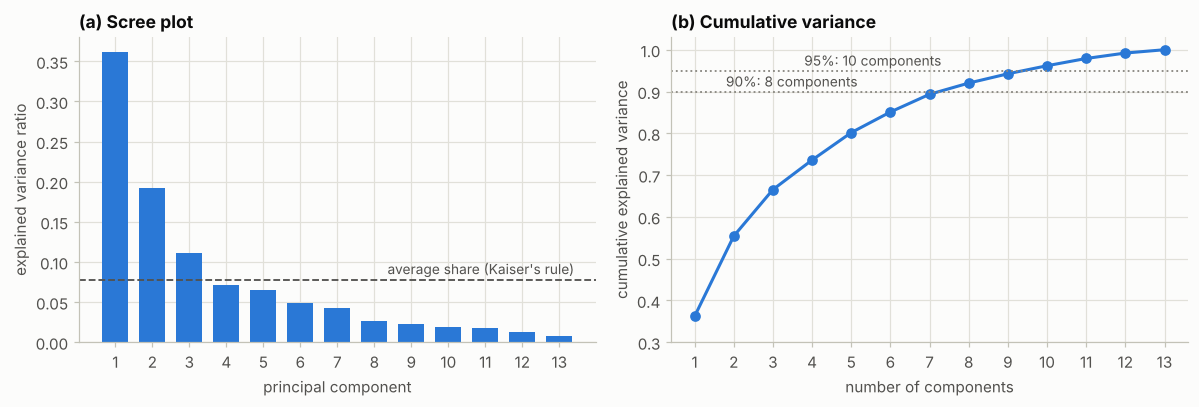

In [10]:
# EXTRA: (d) How many components? Scree plot, cumulative variance and Kaiser's rule
cum_ratio = np.cumsum(pca_full.explained_variance_ratio_)
k90, k95 = np.searchsorted(cum_ratio, 0.90) + 1, np.searchsorted(cum_ratio, 0.95) + 1
k_kaiser = int((pca_full.explained_variance_ > 1).sum())
print("eigenvalues:", pca_full.explained_variance_.round(2))
print(f"components for 90% of the variance: {k90} | for 95%: {k95} | Kaiser's rule (eigenvalue > 1): {k_kaiser}")
print("PCA(n_components=0.95) keeps", PCA(n_components=0.95).fit(Z).n_components_, "components")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
comp = np.arange(1, 14)
ax = axes[0]
ax.bar(comp, pca_full.explained_variance_ratio_, color=PALETTE[0], width=0.7)
ax.axhline(1 / 13, color=INK_SOFT, linestyle="--", linewidth=1.2)
ax.text(13.4, 1 / 13 + 0.008, "average share (Kaiser's rule)", ha="right", fontsize=9, color=INK_SOFT)
ax.set(xticks=comp, xlabel="principal component", ylabel="explained variance ratio", title="(a) Scree plot")
ax = axes[1]
ax.plot(comp, cum_ratio, color=PALETTE[0], marker="o", markersize=6)
for level, k in [(0.90, k90), (0.95, k95)]:
    ax.axhline(level, color=MUTED, linestyle=":", linewidth=1.2)
    ax.annotate(f"{level:.0%}: {k} components", xy=(k, cum_ratio[k - 1]), xytext=(k - 6.2, level + 0.012),
                fontsize=9, color=INK_SOFT)
ax.set(xticks=comp, ylim=(0.3, 1.03), xlabel="number of components", ylabel="cumulative explained variance",
       title="(b) Cumulative variance")
plt.tight_layout()
plt.show()

 5 of 64 components: 54.5% of the variance, reconstruction RMSE 2.92 (pixel scale 0-16)
10 of 64 components: 73.8% of the variance, reconstruction RMSE 2.22 (pixel scale 0-16)
20 of 64 components: 89.4% of the variance, reconstruction RMSE 1.41 (pixel scale 0-16)
40 of 64 components: 98.8% of the variance, reconstruction RMSE 0.47 (pixel scale 0-16)


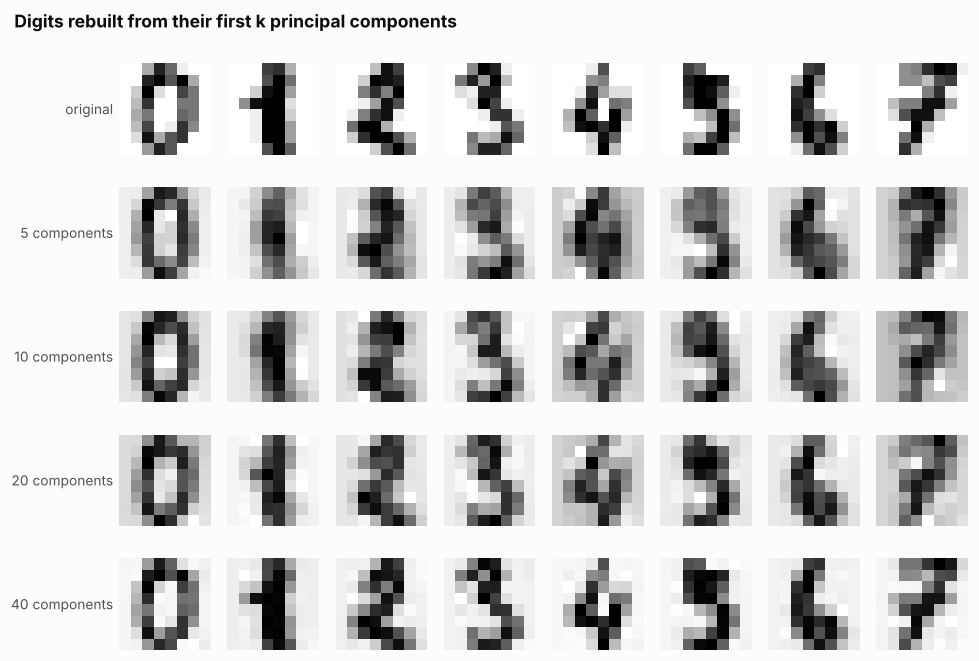

In [11]:
# EXTRA: (e) PCA as compression -- rebuilding handwritten digits from a few components
from sklearn.datasets import load_digits

digit_images = load_digits().data                      # 1,797 images of 8 x 8 pixels, values 0..16
pca_digits = PCA().fit(digit_images)                   # pixels share one scale, so no standardization here
show = digit_images[:8]
ks = [5, 10, 20, 40]
fig, axes = plt.subplots(len(ks) + 1, 8, figsize=(9, 6.2))
for col, img in enumerate(show):
    axes[0, col].imshow(img.reshape(8, 8), cmap="gray_r")
for row, k in enumerate(ks, start=1):
    pk = PCA(n_components=k).fit(digit_images)
    rebuilt = pk.inverse_transform(pk.transform(digit_images))
    rmse = np.sqrt(np.mean((rebuilt - digit_images) ** 2))
    print(f"{k:>2} of 64 components: {np.cumsum(pca_digits.explained_variance_ratio_)[k - 1]:.1%} of the variance, "
          f"reconstruction RMSE {rmse:.2f} (pixel scale 0-16)")
    for col in range(8):
        axes[row, col].imshow(rebuilt[col].reshape(8, 8), cmap="gray_r")
for row, name in enumerate(["original"] + [f"{k} components" for k in ks]):
    axes[row, 0].set_ylabel(name, rotation=0, ha="right", va="center", fontsize=9, color=INK_SOFT)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
fig.suptitle("Digits rebuilt from their first k principal components", x=0.02, ha="left",
             fontweight="bold", color=INK, fontsize=11.5)
plt.tight_layout()
plt.show()

**Output analysis.**

* **(c) Scaling.** Proline's variance in raw units is in the tens of thousands, hundreds of times larger than any other feature's. Without standardization, PC1 is essentially "proline" (weight about 1.0) and explains 99.8% of the variance. The other 12 measurements barely matter. After standardization every feature starts with the same weight, and PC1 explains 36.2%. PCA without scaling ranks features by their units, not by their information.
* **(d) How many components.** The three rules disagree:
  * Kaiser's rule keeps 3 components;
  * 90% of the variance needs 8;
  * 95% needs 10 of the 13.

  The scree plot drops steeply over the first three components and then declines gradually, with no sharp elbow. The wine features are only moderately correlated, so the variance is spread out. A rule is a starting point; the downstream model decides (recipe 6).
* **(e) Compression.** With 5 of the 64 components (55% of the variance) the images are blurred, and only some digits (the 0, 3 and 6) are recognisable. With 20 components (89%) every digit is readable, and with 40 (99%) the images are nearly identical to the originals. The reconstruction error shrinks as the discarded variance does: its square is proportional to the sum of the discarded eigenvalues. This is PCA's other face: a lossy compression that keeps the strongest patterns and drops the fine detail, which is often noise.

---
## 3. Maximizing class separability with LDA

### Summary

* LDA is a dimensionality reduction technique for **supervised** problems, especially classification. PCA maximizes variance without looking at the labels; LDA **maximizes class separability**.
* **Getting ready:** the recipe reuses the wine data.
* **How to do it:**
  * A `Pipeline` chains `StandardScaler()` and `LinearDiscriminantAnalysis(n_components=2)`. A comment notes that `n_components` can be at most $\min(n_\text{features}, n_\text{classes} - 1)$, which is 2 for the three wine classes.
  * The pipeline is fitted with the labels (`fit_transform(X_wine, y_wine)`).
  * In the plot of the two discriminants, the three classes form clear, separate groups (Figure 3.5).
* **How it works:** LDA looks for the axes that maximize the distance between classes while minimizing the variance within each class. It reduces the dimensionality while keeping the information needed for classification. It assumes that every class is Gaussian with a **common covariance matrix**; the book reads this as "each feature has a similar variance (this is why we apply standardization)".
* **PCA versus LDA** (pp. 58–59):

  | | PCA | LDA |
  |---|---|---|
  | Labels | unsupervised | supervised |
  | Objective | retain variance | separate the classes |
  | Output | orthogonal components | discriminants designed for class separability |
  | Typical use | exploration and feature extraction without labels | classification |

  A side-by-side plot shows a slightly more striking separation with LDA, partly because it uses the labels (Figure 3.6).
* **Hands-on exercises:** use labelled data, standardize, apply `LinearDiscriminantAnalysis`, examine the separation and use the reduced features in a model.

### Theory: Fisher's criterion

For $C$ classes with means $\boldsymbol{\mu}_c$ (sizes $n_c$) and overall mean $\boldsymbol{\mu}$, define two scatter matrices:

$$\mathbf{S}_W = \sum_{c=1}^{C}\sum_{i \in c}(\mathbf{x}_i - \boldsymbol{\mu}_c)(\mathbf{x}_i - \boldsymbol{\mu}_c)^\top \qquad \text{(within-class)}$$

$$\mathbf{S}_B = \sum_{c=1}^{C} n_c\,(\boldsymbol{\mu}_c - \boldsymbol{\mu})(\boldsymbol{\mu}_c - \boldsymbol{\mu})^\top \qquad \text{(between-class)}$$

LDA looks for the direction $\mathbf{w}$ that maximizes **Fisher's criterion**, the spread of the class means along $\mathbf{w}$ relative to the spread inside the classes:

$$J(\mathbf{w}) = \frac{\mathbf{w}^\top \mathbf{S}_B\,\mathbf{w}}{\mathbf{w}^\top \mathbf{S}_W\,\mathbf{w}}.$$

The maximizers solve the generalized eigenproblem $\mathbf{S}_B\mathbf{w} = \lambda\,\mathbf{S}_W\mathbf{w}$: they are eigenvectors of $\mathbf{S}_W^{-1}\mathbf{S}_B$, and each eigenvalue is the value of $J$ along its direction.

* **At most $C - 1$ discriminants.** $\mathbf{S}_B$ is a sum of $C$ rank-one terms whose vectors $\boldsymbol{\mu}_c - \boldsymbol{\mu}$ are linearly dependent (their weighted sum is zero). So it has rank at most $C - 1$, and only $C - 1$ eigenvalues are non-zero: 2 for the three wine classes, 9 for the ten digits.
* **`explained_variance_ratio_`** for LDA is $\lambda_k / \sum_j \lambda_j$: the share of the *between-class separation* captured by each discriminant, not a share of the total variance.
* **The probabilistic view.** Suppose every class is Gaussian, $\mathcal{N}(\boldsymbol{\mu}_c, \boldsymbol{\Sigma})$, with the **same** covariance matrix $\boldsymbol{\Sigma}$. Then the Bayes classifier is linear:

$$\delta_c(\mathbf{x}) = \mathbf{x}^\top\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}_c - \tfrac{1}{2}\,\boldsymbol{\mu}_c^\top\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}_c + \log \pi_c .$$

  This is what `LinearDiscriminantAnalysis.predict` computes, and the discriminants span the directions $\boldsymbol{\Sigma}^{-1}(\boldsymbol{\mu}_c - \boldsymbol{\mu})$. "Common covariance matrix" means that **all classes share one covariance matrix**: their clouds have the same shape and orientation. It does not mean that the features have similar variances.
* **LDA is invariant to rescaling the features.** If $\mathbf{x}' = \mathbf{D}\mathbf{x}$ for an invertible $\mathbf{D}$ (a diagonal $\mathbf{D}$ is what standardization does), then:
  * the scatter matrices become $\mathbf{D}\mathbf{S}_B\mathbf{D}^\top$ and $\mathbf{D}\mathbf{S}_W\mathbf{D}^\top$;
  * the optimal direction becomes $\mathbf{w}' = \mathbf{D}^{-\top}\mathbf{w}$;
  * the projections stay the same: $\mathbf{w}'^\top\mathbf{x}' = \mathbf{w}^\top\mathbf{x}$.

  So standardizing before LDA changes nothing in the projection, unlike PCA (extra b).
* **Overfitting.** $\mathbf{S}_W$ must be inverted. With many features and few samples it is nearly singular, and LDA finds directions that separate the *training* classes even when the labels are random (extra c). The remedies are:
  * shrinkage (`solver="lsqr"` or `"eigen"` with `shrinkage="auto"`, the Ledoit–Wolf estimator);
  * PCA first;
  * more data.

| | PCA | LDA |
|---|---|---|
| Uses the labels | no | yes |
| Maximizes | variance $\mathbf{w}^\top\mathbf{S}\mathbf{w}$ | Fisher's ratio $J(\mathbf{w})$ |
| Maximum number of components | $\min(n, p)$ | $\min(p, C - 1)$ |
| Directions | orthogonal | orthogonal only with respect to $\mathbf{S}_W$ |
| Changes when features are rescaled | yes | no |
| Can also classify | no | yes (`predict`) |

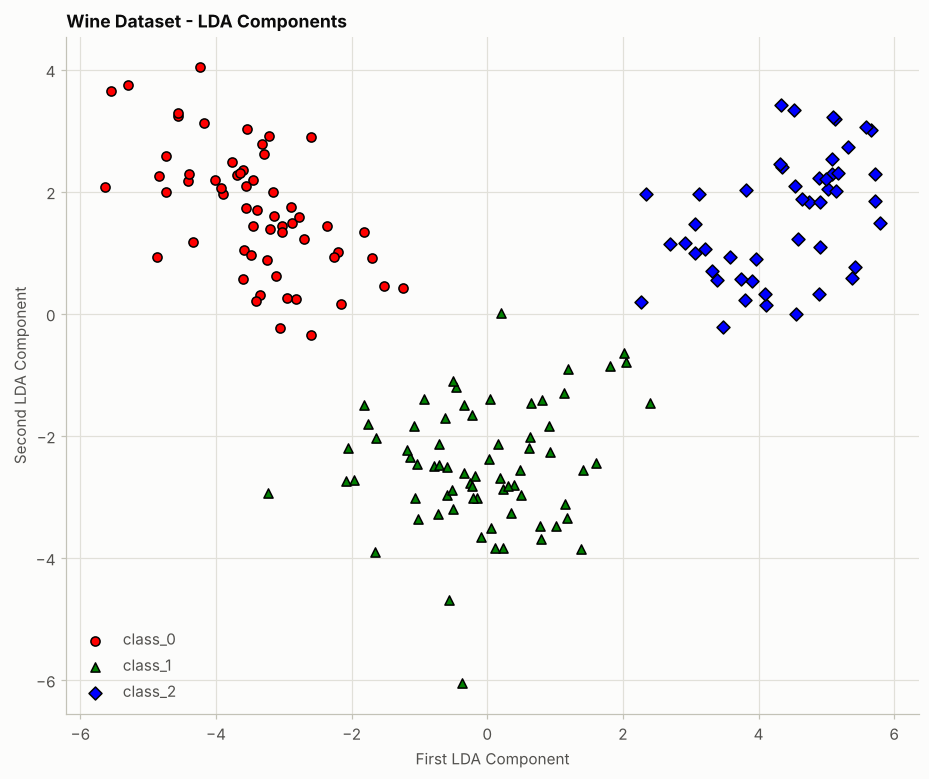

In [12]:
# BOOK CODE: Maximizing class separability with LDA -- how to do it (pp. 55-56)
# Load libraries
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Split wine dataset by features and target
X_wine, y_wine = wine.data, wine.target

# Create LDA pipeline for wine dataset
lda_pipeline_wine = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(n_components=2))  # min(n_features, n_classes - 1) for wine dataset is 2
])

# Fit and transform the wine data
X_lda_wine = lda_pipeline_wine.fit_transform(X_wine, y_wine)

# Visualize LDA transformation for wine dataset
plt.figure(figsize=(10, 8))

# Define markers and colors for each class
shapes = ['o', '^', 'D']
colors = ['r', 'g', 'b']

# Plot each class with different marker and color
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = y_wine == i
    plt.scatter(X_lda_wine[mask, 0], X_lda_wine[mask, 1],
               c=color, marker=shape, edgecolor='black',
               label=wine.target_names[i])

plt.xlabel('First LDA Component')
plt.ylabel('Second LDA Component')
plt.title('Wine Dataset - LDA Components')
plt.legend()
plt.show()

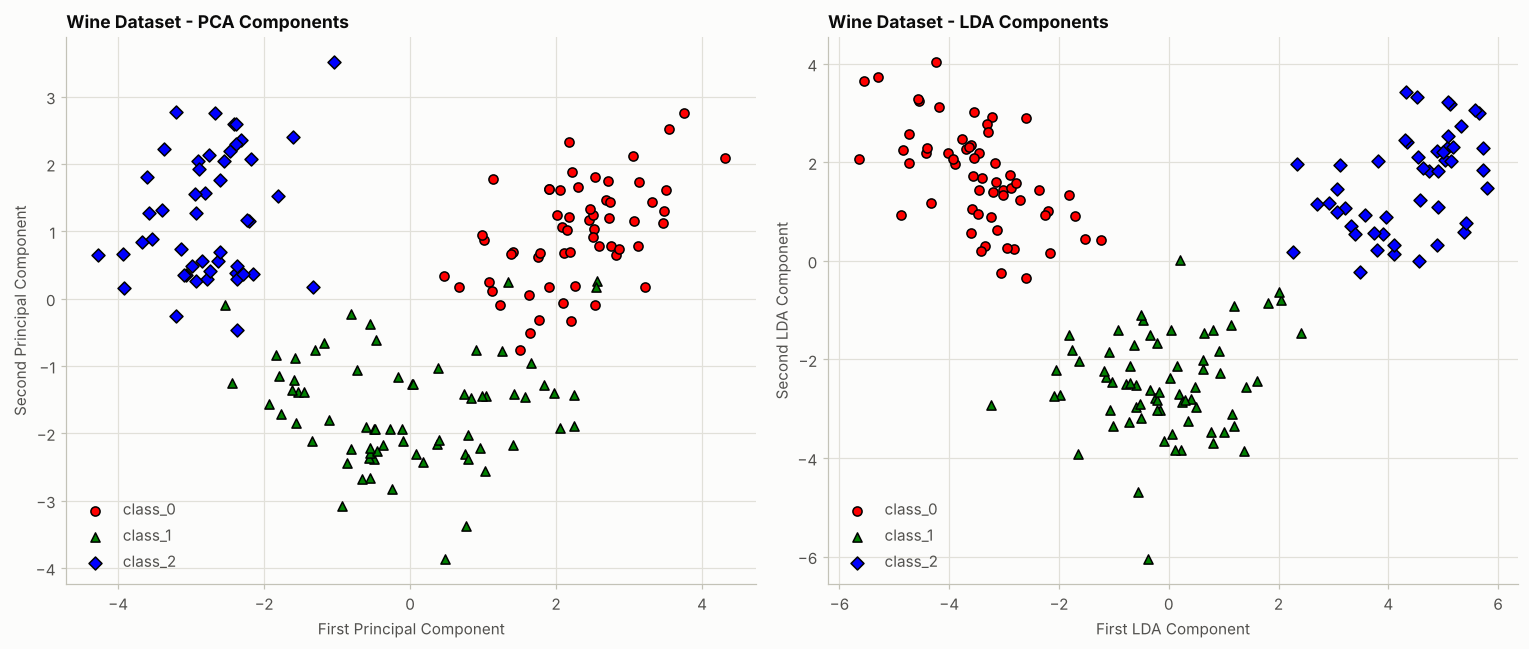

In [13]:
# BOOK CODE: Differences between PCA and LDA -- side-by-side plots (pp. 58-59)
# Create side-by-side plots
plt.figure(figsize=(14, 6))

plt.subplot(121)
shapes = ['o', '^', 'D']
colors = ['r', 'g', 'b']

for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = y_wine == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, marker=shape, edgecolor='black',
               label=wine.target_names[i])

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Wine Dataset - PCA Components')
plt.legend()

plt.subplot(122)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = y_wine == i
    plt.scatter(X_lda_wine[mask, 0], X_lda_wine[mask, 1],
               c=color, marker=shape, edgecolor='black',
               label=wine.target_names[i])

plt.xlabel('First LDA Component')
plt.ylabel('Second LDA Component')
plt.title('Wine Dataset - LDA Components')
plt.legend()

plt.tight_layout()
plt.show()

**Output analysis.**

* **Figure 3.5 reproduced.** On the two discriminants the three cultivars form three compact groups with essentially no overlap. Class 1 sits between the other two along the first discriminant, and the second discriminant pulls it away from both.
* **Figure 3.6 reproduced.** Side by side, the LDA groups are tighter and further apart than the PCA groups, as the book says. The reason is the objective: LDA was *told* the classes and chose the projection that separates them best, while PCA chose the projection with the most variance and separates the classes only as a by-product.
* **A caution.** Both plots use all 178 wines, and LDA saw their labels. Its separation is therefore measured on the data it was fitted to. Extras (c) and (d) show why that matters and measure the separation on held-out data instead.

In [14]:
# EXTRA: (a) Fisher's criterion by hand -- scatter matrices and the generalized eigenproblem
Zw = StandardScaler().fit_transform(X_wine)
mu = Zw.mean(axis=0)
S_W = np.zeros((Zw.shape[1], Zw.shape[1]))
S_B = np.zeros_like(S_W)
for c in np.unique(y_wine):
    Zc = Zw[y_wine == c]
    mu_c = Zc.mean(axis=0)
    S_W += (Zc - mu_c).T @ (Zc - mu_c)                         # spread inside class c
    S_B += len(Zc) * np.outer(mu_c - mu, mu_c - mu)             # spread of the class means

ev, evec = np.linalg.eig(np.linalg.solve(S_W, S_B))              # eigenvectors of S_W^-1 S_B
order = np.argsort(ev.real)[::-1]
ev, evec = ev.real[order], evec.real[:, order]
lda = lda_pipeline_wine.named_steps["lda"]

print("rank of S_B:", np.linalg.matrix_rank(S_B), "-> at most 2 discriminants for 3 classes")
print("eigenvalues of S_W^-1 S_B (largest 4):", ev[:4].round(4))
print("share of the separation, by hand     :", (ev[:2] / ev[:2].sum()).round(4))
print("sklearn explained_variance_ratio_    :", lda.explained_variance_ratio_.round(4))
proj = Zw @ evec[:, :2]
print("|correlation| with the book's X_lda_wine, per discriminant:",
      [round(abs(np.corrcoef(proj[:, k], X_lda_wine[:, k])[0, 1]), 6) for k in range(2)])


def fisher_J(w):
    return (w @ S_B @ w) / (w @ S_W @ w)


print(f"Fisher's criterion J along LD1: {fisher_J(evec[:, 0]):.3f} | along PC1: {fisher_J(pca_full.components_[0]):.3f}")

rank of S_B: 2 -> at most 2 discriminants for 3 classes
eigenvalues of S_W^-1 S_B (largest 4): [9.0817 4.1285 0.     0.    ]
share of the separation, by hand     : [0.6875 0.3125]
sklearn explained_variance_ratio_    : [0.6875 0.3125]
|correlation| with the book's X_lda_wine, per discriminant: [np.float64(1.0), np.float64(1.0)]
Fisher's criterion J along LD1: 9.082 | along PC1: 3.999


In [15]:
# EXTRA: (b) Does LDA need the scaler? The same projection with and without StandardScaler
X_lda_raw = LinearDiscriminantAnalysis(n_components=2).fit_transform(X_wine, y_wine)
print(f"largest difference between the LDA projections with and without scaling (up to sign): "
      f"{np.abs(np.abs(X_lda_wine) - np.abs(X_lda_raw)).max():.1e}")
X_pca_raw = PCA(n_components=2).fit_transform(X_wine)
print(f"for comparison, PCA: |correlation| between PC1 with and without scaling = "
      f"{abs(np.corrcoef(X_pca[:, 0], X_pca_raw[:, 0])[0, 1]):.3f}")

largest difference between the LDA projections with and without scaling (up to sign): 1.6e-14
for comparison, PCA: |correlation| between PC1 with and without scaling = 0.622


LDA classifier, accuracy on its own training data: 1.0
accuracy on fresh noise                          : 0.333
5-fold cross-validated accuracy                  : 0.3 (chance = 1/3)


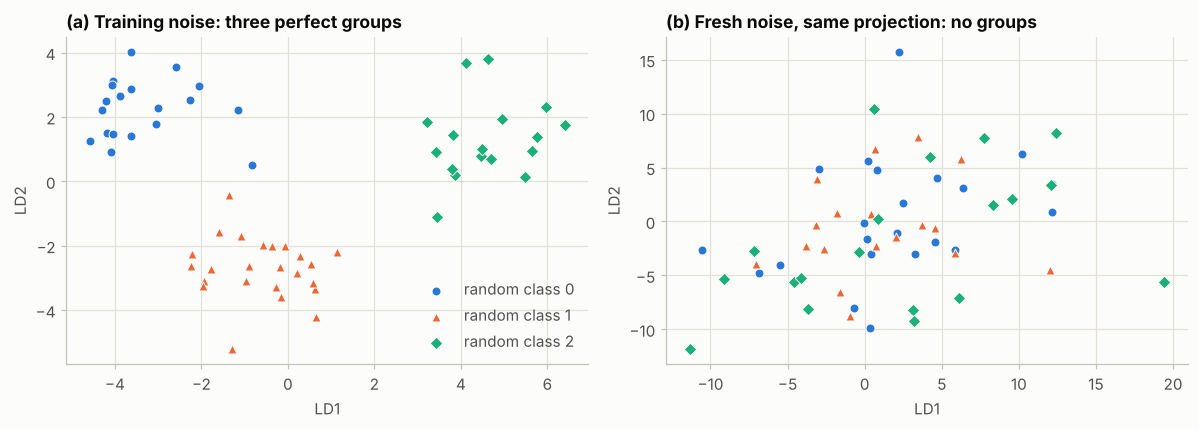

In [16]:
# EXTRA: (c) A supervised projection can "separate" classes that do not exist -- random labels, many features
from sklearn.model_selection import StratifiedKFold, cross_val_score

rng = np.random.default_rng(0)
X_noise = rng.normal(size=(60, 50))          # 60 samples, 50 features of pure noise
y_noise = rng.integers(0, 3, size=60)        # 3 random "classes"
X_noise_new = rng.normal(size=(60, 50))      # fresh samples from the same noise
y_noise_new = rng.integers(0, 3, size=60)

lda_noise = LinearDiscriminantAnalysis(n_components=2).fit(X_noise, y_noise)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
print("LDA classifier, accuracy on its own training data:", lda_noise.score(X_noise, y_noise))
print("accuracy on fresh noise                          :", round(lda_noise.score(X_noise_new, y_noise_new), 3))
print("5-fold cross-validated accuracy                  :",
      round(cross_val_score(LinearDiscriminantAnalysis(), X_noise, y_noise, cv=cv5).mean(), 3), "(chance = 1/3)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, X_show, y_show, title in [
    (axes[0], X_noise, y_noise, "(a) Training noise: three perfect groups"),
    (axes[1], X_noise_new, y_noise_new, "(b) Fresh noise, same projection: no groups"),
]:
    emb = lda_noise.transform(X_show)
    for cls, (color, marker) in enumerate(zip(PALETTE, ["o", "^", "D"])):
        m = y_show == cls
        ax.scatter(emb[m, 0], emb[m, 1], s=34, color=color, marker=marker, edgecolor=SURFACE, linewidth=0.6,
                   label=f"random class {cls}")
    ax.set(xlabel="LD1", ylabel="LD2", title=title)
axes[0].legend(loc="best")
plt.tight_layout()
plt.show()

In [17]:
# EXTRA: (d) Measuring separation honestly -- k-NN accuracy in each 2-D space, projection fitted inside every fold
from sklearn.neighbors import KNeighborsClassifier

spaces = {
    "PCA, 2 components": PCA(n_components=2),
    "LDA, 2 discriminants": LinearDiscriminantAnalysis(n_components=2),
    "all 13 standardized features": "passthrough",
}
rows = []
for name, reducer in spaces.items():
    model = Pipeline([("scaler", StandardScaler()), ("reduce", reducer), ("knn", KNeighborsClassifier())])
    scores = cross_val_score(model, X_wine, y_wine, cv=cv5)
    rows.append((name, scores.mean(), scores.std()))
display(pd.DataFrame(rows, columns=["space", "5-fold CV accuracy (k-NN)", "std"]).set_index("space").round(3))

,5-fold CV accuracy (k-NN),std
space,,
"PCA, 2 components",0.966,0.011
"LDA, 2 discriminants",0.989,0.014
all 13 standardized features,0.961,0.013


**Output analysis.**

* **(a) Fisher by hand:**
  * $\mathbf{S}_B$ has rank 2, so only two eigenvalues are non-zero; the rest are round-off.
  * Their shares match scikit-learn's `explained_variance_ratio_` (about 69% and 31% of the between-class separation).
  * The hand-made projections correlate perfectly with the book's.
  * Fisher's criterion along LD1 is more than twice as high as along PC1 (about 9.1 against 4.0). That gap is the difference between "most variance" and "best separation"; PC1 still separates reasonably well, because on the wine data the classes differ along the main direction of variance.
* **(b) Scaling.** With and without `StandardScaler`, the LDA projections agree to round-off, as the invariance argument predicts. The book's reason for scaling ("each feature has a similar variance") does not apply to LDA: the scaler does no harm in the pipeline, but it changes nothing. For PCA the same scaler changes PC1 substantially: the two versions of PC1 correlate at only 0.62.
* **(c) Overfitting.** With 50 noise features and 60 samples, LDA classifies its own training data perfectly and draws three neat groups. On fresh noise from the same distribution, and in cross-validation, it is at chance level. A beautiful LDA plot of the training data proves nothing by itself: fit the projection inside the cross-validation, or plot held-out data.
* **(d) Honest separation.** With the projection fitted inside each fold, k-NN in LDA's 2-D space is the most accurate of the three (0.989), better than k-NN on all 13 standardized features (0.961). PCA's 2-D space does as well as all 13 features (0.966). On the wine data the class information really is concentrated in two discriminant directions, so the book's Figure 3.6 is not an overfitting artefact.

---
## 4. t-SNE and data visualization

### Summary

* t-SNE maps high-dimensional data into two or three dimensions for **visualization**. It is especially good at revealing the structure of complex datasets: patterns, clusters and relationships.
* **Getting ready:**
  * The recipe switches to the handwritten digits dataset, which the book calls "MNIST".
  * It quotes the UCI description: $32 \times 32$ bitmaps from 43 writers are divided into $4 \times 4$ blocks, and the "on" pixels are counted in each block. This gives $8 \times 8$ images with values from 0 to 16, which reduces the dimensionality and gives invariance to small distortions.
  * The data are loaded with `load_digits()`.
* **How to do it:**
  * A `Pipeline` chains `StandardScaler()` and `TSNE(n_components=2, random_state=2024)` and is applied to the digit features.
  * The map is plotted with one colour per digit (the `Paired` colormap and a custom legend).
  * The book's reading of the map (Figure 3.7):
    * "similar to LDA, t-SNE excels at class separation", here for 10 classes;
    * many 9s lie close to 7s and 4s, which are written similarly;
    * the 0s form an isolated cluster in the bottom-left corner, since 0 resembles no other digit.
* **How it works:**
  1. t-SNE converts high-dimensional Euclidean distances into conditional probabilities that represent similarities.
  2. It looks for a 2-D or 3-D map that preserves those similarities as closely as possible.
  3. Similar points end up close together and dissimilar points far apart, revealing clusters.
* **Hands-on exercises:** understand the data, put the features on a similar scale, apply `TSNE`, plot the result and analyse the clusters.
* **There's more:** choosing the right technique is essential, different techniques serve different purposes, and they can sometimes be combined (recipe 5).

### Theory: how t-SNE builds its map

t-SNE (van der Maaten & Hinton, 2008) matches two sets of similarities: one between the original points, one between their positions on the map.

**1. Similarities in the original space.** Around each point $\mathbf{x}_i$, place a Gaussian with its own width $\sigma_i$ and turn distances into probabilities. Then symmetrize:

$$p_{j\mid i} = \frac{\exp\!\big(-\lVert \mathbf{x}_i - \mathbf{x}_j\rVert^2 / 2\sigma_i^2\big)}{\sum_{k \ne i}\exp\!\big(-\lVert \mathbf{x}_i - \mathbf{x}_k\rVert^2 / 2\sigma_i^2\big)}, \qquad p_{ij} = \frac{p_{j\mid i} + p_{i\mid j}}{2n}.$$

**2. Perplexity sets the widths.** Each $\sigma_i$ is found by binary search so that the distribution $P_i$ has the requested **perplexity**:

$$\operatorname{Perp}(P_i) = 2^{H(P_i)}, \qquad H(P_i) = -\sum_j p_{j\mid i}\log_2 p_{j\mid i}.$$

Perplexity is roughly the number of effective neighbours of each point (default 30). Points in dense regions get a narrow Gaussian, points in sparse regions a wide one.

**3. Similarities on the map.** Here t-SNE uses a Student-t distribution with one degree of freedom:

$$q_{ij} = \frac{\big(1 + \lVert \mathbf{y}_i - \mathbf{y}_j\rVert^2\big)^{-1}}{\sum_{k \ne l}\big(1 + \lVert \mathbf{y}_k - \mathbf{y}_l\rVert^2\big)^{-1}}.$$

Its heavy tails let moderately distant points sit far apart on the map. This solves the *crowding problem*: a 2-D map has far less room than a 64-D space to keep all the moderate distances.

**4. The objective.** The map minimizes the Kullback–Leibler divergence, reported by scikit-learn as `kl_divergence_`:

$$C = \mathrm{KL}(P \,\Vert\, Q) = \sum_{i \ne j} p_{ij}\,\log\frac{p_{ij}}{q_{ij}}.$$

KL is asymmetric. Placing true neighbours far apart (large $p_{ij}$, small $q_{ij}$) is very costly, while placing non-neighbours close together is cheap. **Local structure is preserved; global geometry is not.**

**5. The optimization.** The gradient is

$$\frac{\partial C}{\partial \mathbf{y}_i} = 4\sum_j (p_{ij} - q_{ij})(\mathbf{y}_i - \mathbf{y}_j)\big(1 + \lVert \mathbf{y}_i - \mathbf{y}_j\rVert^2\big)^{-1},$$

which acts like attractive and repulsive forces between points. scikit-learn runs gradient descent with momentum:

* an *early exaggeration* phase multiplies $P$ by 12 so that clusters can form;
* `learning_rate="auto"`, which is $\max(n / 12 / 4,\, 50)$, and `init="pca"` are the defaults since version 1.2;
* `max_iter=1000` iterations (the parameter was called `n_iter` before version 1.5);
* the Barnes–Hut approximation (`method="barnes_hut"`, `angle=0.5`) costs $O(n \log n)$ per iteration instead of $O(n^2)$.

**What a t-SNE map cannot tell you** (Wattenberg et al., 2016):

* Cluster **sizes** and **distances between clusters** are not meaningful.
* The layout is arbitrary up to rotation and reflection, and changes with the perplexity, the seed and the library version.
* At low perplexity, apparent clusters can appear even in random noise.
* `TSNE` has **no `transform` method**: new points cannot be placed on an existing map, so t-SNE cannot be a preprocessing step for a predictive model. It is a visualization tool.

**How to judge a map: trustworthiness.** Trustworthiness (Venna & Kaski, 2001) measures how many of each point's neighbours on the map are also its neighbours in the original space:

$$T(k) = 1 - \frac{2}{nk(2n - 3k - 1)}\sum_{i=1}^{n}\sum_{j \in \mathcal{U}_i^{(k)}} \big(r(i, j) - k\big).$$

Here $\mathcal{U}_i^{(k)}$ is the set of map neighbours of $i$ that are *not* among its $k$ nearest neighbours in the original space, and $r(i, j)$ is their rank in the original space. $T = 1$ means every map neighbour is a true neighbour (`sklearn.manifold.trustworthiness`).

**About the data.** `load_digits` is the UCI *Optical Recognition of Handwritten Digits* dataset: 1,797 images of $8 \times 8$ pixels. MNIST is a different, larger dataset: 70,000 images of $28 \times 28$ pixels (LeCun et al., 1998).

In [18]:
# BOOK CODE: t-SNE and data visualization -- getting ready (p. 60)
# Load libraries
from sklearn.datasets import load_digits

# Load dataset
digits = load_digits()

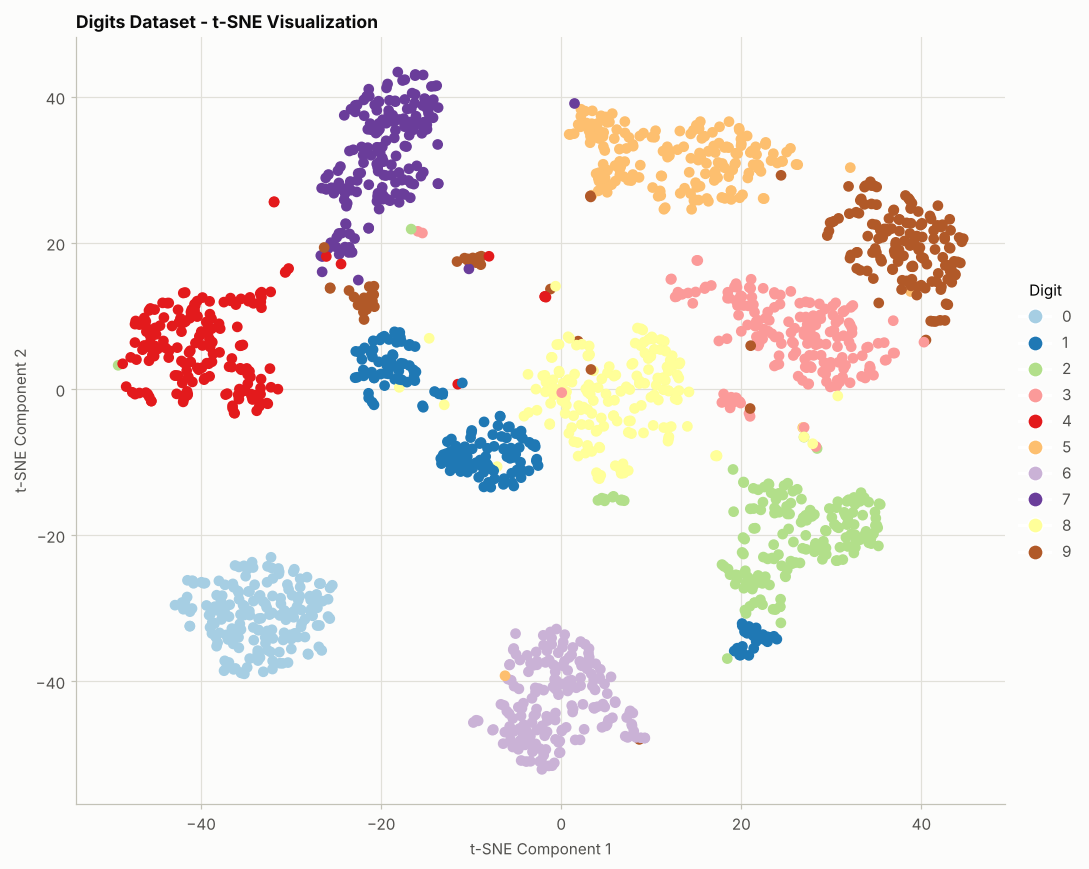

In [19]:
# BOOK CODE: t-SNE and data visualization -- how to do it (pp. 61-62)
# Load libraries
from sklearn.manifold import TSNE

# Create t-SNE pipeline
tsne_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('tsne', TSNE(n_components=2, random_state=2024))
])

# Fit and transform the digits data
X_tsne = tsne_pipeline.fit_transform(digits.data)
# Visualize t-SNE results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=digits.target, cmap='Paired', label=digits.target)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('Digits Dataset - t-SNE Visualization')

# Create legend
legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                             markerfacecolor=plt.cm.Paired(i/9),
                             label=str(i), markersize=10)
                  for i in range(10)]
plt.legend(handles=legend_elements, title='Digit', loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

**Output analysis.**

* **Groups without labels.** Most digits form one well-defined group, with a few points stranded in the "wrong" group (badly written digits, or digits that really look alike). t-SNE never saw the labels; the colours were added afterwards. The groups exist because images of the same digit are each other's nearest neighbours in the 64-pixel space.
* **The book's observations hold in this run.** The 0s form a tight, isolated group in the bottom-left corner, as the book describes. Most 9s form a group in the top right next to the 3s and 5s, and two small islands of 9s sit between the 7s and the 4s. With `init="pca"` (the default since scikit-learn 1.2) and a fixed `random_state`, the global layout is reproducible, which is presumably why this map matches the book's description.
* **Something the book does not mention.** The 1s split into three islands, one of them next to the 2s. Ones are written in different styles (for example with or without a base stroke), and t-SNE probably keeps each style's neighbourhood together.
* **How far to trust such readings:**
  * That the 0s form a tight, isolated group is a statement about neighbourhoods, which t-SNE preserves.
  * That 9s are "close to" 7s and 4s is a statement about distances *between* groups, which t-SNE does not preserve reliably. Positions also change with the perplexity, the seed and the version. Such statements should be checked in the original space before being believed.
* **A note on the plotting code.** `label=digits.target` turns the whole label array into a single text label. That is harmless only because the legend is built by hand from `legend_elements`.

images: (1797, 8, 8) | feature matrix: (1797, 64) | pixel values: 0 to 16
images per digit: [178, 182, 177, 183, 181, 182, 181, 179, 174, 180]
pixels that are 0 in every image (constant features): 3


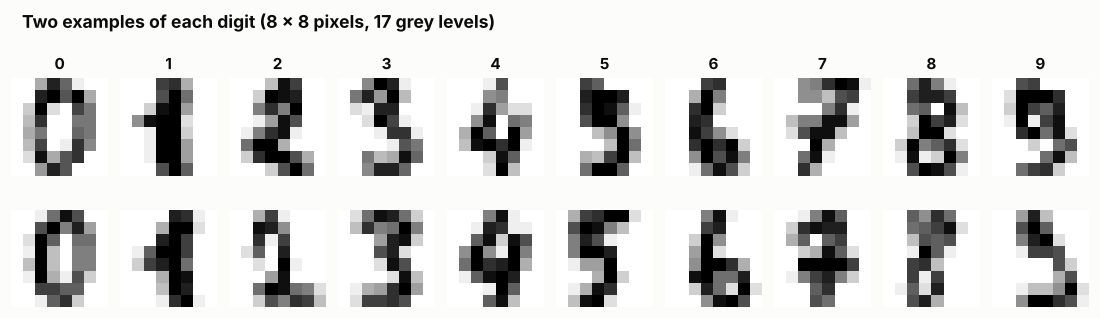

In [20]:
# EXTRA: (a) What the digits data look like -- and why they are not MNIST
print("images:", digits.images.shape, "| feature matrix:", digits.data.shape,
      "| pixel values:", int(digits.data.min()), "to", int(digits.data.max()))
print("images per digit:", np.bincount(digits.target).tolist())
print("pixels that are 0 in every image (constant features):", int((digits.data.std(axis=0) == 0).sum()))

fig, axes = plt.subplots(2, 10, figsize=(10, 2.9), gridspec_kw={"hspace": 0.12, "wspace": 0.12})
for d in range(10):
    idx = np.flatnonzero(digits.target == d)[:2]
    for row in range(2):
        ax = axes[row, d]
        ax.imshow(digits.images[idx[row]], cmap="gray_r")
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(False)
    axes[0, d].set_title(str(d), loc="center", fontsize=10)
fig.suptitle("Two examples of each digit (8 x 8 pixels, 17 grey levels)", x=0.02, ha="left",
             fontweight="bold", color=INK, fontsize=11.5)
fig.subplots_adjust(left=0.01, right=0.99, top=0.80, bottom=0.02)
plt.show()

perplexity   5: KL divergence 0.977 | trustworthiness (k=10) 0.9820


perplexity  30: KL divergence 0.837 | trustworthiness (k=10) 0.9863


perplexity 100: KL divergence 0.726 | trustworthiness (k=10) 0.9837


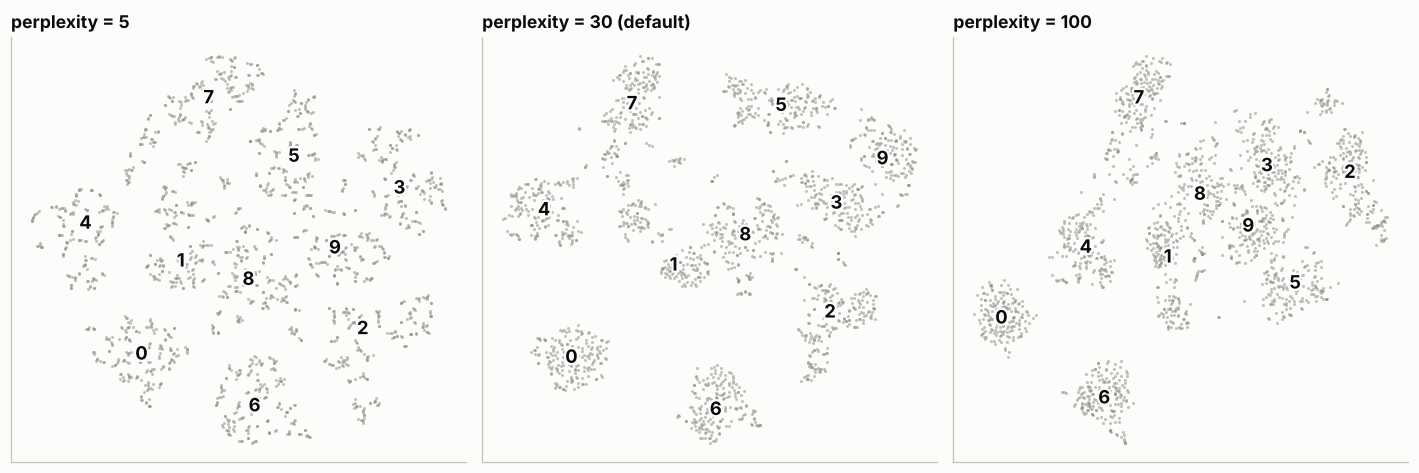

In [21]:
# EXTRA: (b) The perplexity setting -- the same data, three maps
from sklearn.manifold import trustworthiness

X_digits_std = StandardScaler().fit_transform(digits.data)
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, perplexity in zip(axes, [5, 30, 100]):
    tsne_p = TSNE(perplexity=perplexity, random_state=2024)
    emb = tsne_p.fit_transform(X_digits_std)
    trust = trustworthiness(X_digits_std, emb, n_neighbors=10)
    print(f"perplexity {perplexity:>3}: KL divergence {tsne_p.kl_divergence_:.3f} | trustworthiness (k=10) {trust:.4f}")
    ax.scatter(emb[:, 0], emb[:, 1], s=4, color=MUTED, alpha=0.5, linewidth=0)
    label_groups(ax, emb, digits.target)
    ax.set(xticks=[], yticks=[], title=f"perplexity = {perplexity}" + (" (default)" if perplexity == 30 else ""))
plt.tight_layout()
plt.show()

In [22]:
# EXTRA: (c) Which 2-D map keeps the neighbourhoods? Trustworthiness of PCA, LDA and t-SNE -- and no transform()
maps = {
    "PCA, 2 components": PCA(n_components=2).fit_transform(X_digits_std),
    "LDA, 2 discriminants": LinearDiscriminantAnalysis(n_components=2).fit_transform(X_digits_std, digits.target),
    "t-SNE (the book's pipeline)": X_tsne,
}
trust_table = pd.Series({name: trustworthiness(X_digits_std, emb, n_neighbors=10) for name, emb in maps.items()},
                        name="trustworthiness (k=10)")
display(trust_table.round(4).to_frame())

print("TSNE has a transform method:", hasattr(TSNE(), "transform"))
try:
    tsne_pipeline.transform(digits.data[:5])
except AttributeError as err:
    print("tsne_pipeline.transform(new_images) ->", type(err).__name__ + ":", err)

,trustworthiness (k=10)
"PCA, 2 components",0.8163
"LDA, 2 discriminants",0.7646
t-SNE (the book's pipeline),0.9863


TSNE has a transform method: False
tsne_pipeline.transform(new_images) -> AttributeError: This 'Pipeline' has no attribute 'transform'


**Output analysis.**

* **(a) The data.** 1,797 images of $8 \times 8$ pixels with values 0 to 16, about 180 per digit. Three border pixels are 0 in every image. The images are coarse but readable. This is the UCI digits set, not MNIST.
* **(b) Perplexity:**
  * At perplexity 5 each point only looks at a handful of neighbours, and the digits split into several sub-clusters.
  * At 30 (the default) the ten digits are clean groups.
  * At 100 the groups become rounder and are pulled closer together, because each point now considers about a hundred neighbours.

  The KL divergences cannot be compared across perplexities, because each perplexity defines a different $P$. Trustworthiness can, and it stays high (about 0.98) for all three. They are three equally valid views of the same neighbourhoods, which is exactly why a single t-SNE picture should not be over-interpreted.
* **(c) Neighbourhoods:**
  * t-SNE keeps about 99% trustworthiness: almost every point's neighbours on the map are true neighbours.
  * PCA's best plane only reaches about 0.82, because two linear directions cannot hold ten digit classes apart.
  * LDA scores lowest (about 0.76). It squeezes every class towards its mean to separate the classes, which destroys the neighbourhood structure *inside* each class.

  Each method preserves what its objective asks for.
* **No `transform`.** `TSNE` has no `transform`, and so neither does a pipeline that ends with it. A t-SNE map cannot be extended to new images, which is why recipe 5 and the official notebook classify t-SNE as a visualization tool and warn against using it as a step in a predictive pipeline.

---
## 5. Selecting the right technique

### Summary

* Choosing the right technique is essential for high-dimensional data, and the techniques can be combined. A flowchart (Figure 3.8) summarizes the decision.
* **Guidelines for selecting a technique:**
  * **Supervised or unsupervised?** With labels and the goal of separating classes, use LDA. Without labels, to capture variance, use PCA. t-SNE visualizes data either way.
  * **Variance or class separability?** PCA retains variance; LDA enhances class separability; t-SNE excels at showing complex relationships and clusters.
  * **Feature extraction or visualization?** PCA and LDA produce features for models; t-SNE is designed for visualization.
  * **Efficiency:**
    * PCA is computationally efficient and handles large datasets.
    * LDA needs class means and covariance matrices, so it is less efficient with very high dimensions or many classes.
    * t-SNE's iterative optimization is computationally intensive.
  * **Understanding the results:**
    * PCA's components are linear combinations of features and can be hard to interpret.
    * The book calls LDA's discriminants "more interpretable in terms of class separation".
    * t-SNE gives a picture, with no direct feature contributions.
* **Table 3.1** compares the three techniques:

  | Technique | Type | Purpose | Key features | Best use cases |
  |---|---|---|---|---|
  | PCA | unsupervised | dimensionality reduction | maximizes variance; linear combinations of features | exploratory analysis, noise reduction, feature extraction |
  | LDA | supervised | dimensionality reduction | maximizes class separability; linear discriminants | classification tasks where class separation matters |
  | t-SNE | unsupervised | visualization | non-linear mapping; reveals clusters; preserves local structure | visualizing high-dimensional data, exploratory analysis |

* **Practical steps for selection:**
  1. state the goal (better models or visual insight);
  2. understand the data (labelled or not, dimensionality);
  3. weigh the dataset size against the computational resources;
  4. when unsure, try several techniques, for example PCA followed by t-SNE;
  5. evaluate the result with model metrics or visual clarity.

### Theory: cost, reach and other options

| Technique | Cost of fitting ($n$ samples, $p$ features) | Handles new data | Typical role |
|---|---|---|---|
| PCA | $O(np\min(n, p))$ for a full SVD; randomized SVD for large data | `transform`, `inverse_transform` | compression, denoising, preprocessing |
| LDA | $O(np^2 + p^3)$: scatter matrices plus an eigenproblem | `transform` and `predict` | supervised reduction, classification |
| t-SNE | $O(n \log n)$ per iteration (Barnes–Hut), about 1,000 iterations; $O(n^2)$ exact | no | visualization only |

* **PCA then t-SNE.** Running t-SNE on the first 30 to 50 principal components is standard practice (van der Maaten & Hinton, 2008; Kobak & Berens, 2019). It removes noise dimensions and makes the distance computations cheaper, while the neighbourhoods barely change. This is the combination the book's practical step 4 suggests.
* **A precision on interpretability.** PCA's components and LDA's discriminants are *both* linear combinations of all the features, and neither set of weights is easier to read. What differs is the meaning of the axes: an LDA axis means "the direction that separates these classes", a PCA axis means "the direction of greatest variance".
* **Other scikit-learn tools for the same job:**

  | Tool | What it does |
  |---|---|
  | `TruncatedSVD` | PCA without centring; works on sparse matrices such as the text features of Chapter 9 |
  | `KernelPCA` | non-linear PCA through a kernel (the kernel trick of Chapter 7); has `transform` |
  | `Isomap`, `LocallyLinearEmbedding`, `SpectralEmbedding` | manifold learning |
  | `NMF`, `FastICA` | parts-based and independent components |
  | `GaussianRandomProjection`, `SparseRandomProjection` | random projections that approximately preserve distances (Johnson–Lindenstrauss lemma) |

  UMAP, a popular alternative to t-SNE, lives in the separate `umap-learn` package.

In [23]:
# EXTRA: Cost and quality of each technique on the digits data, and PCA followed by t-SNE
# (run times depend on the machine; the ratios are what matter)
import time

def run_timed(make_embedding):
    start = time.perf_counter()
    embedding = make_embedding()
    return embedding, time.perf_counter() - start

candidates = {
    "PCA": lambda: PCA(n_components=2).fit_transform(X_digits_std),
    "LDA": lambda: LinearDiscriminantAnalysis(n_components=2).fit_transform(X_digits_std, digits.target),
    "t-SNE": lambda: TSNE(random_state=2024).fit_transform(X_digits_std),
    "PCA (30 components), then t-SNE": lambda: TSNE(random_state=2024).fit_transform(
        PCA(n_components=30).fit_transform(X_digits_std)),
}
rows = []
for name, make in candidates.items():
    emb, seconds = run_timed(make)
    rows.append((name, seconds, trustworthiness(X_digits_std, emb, n_neighbors=10)))
cost = pd.DataFrame(rows, columns=["technique", "fit time (s)", "trustworthiness (k=10)"]).set_index("technique")
cost["times slower than PCA"] = cost["fit time (s)"] / cost.loc["PCA", "fit time (s)"]
display(cost.round({"fit time (s)": 3, "trustworthiness (k=10)": 4, "times slower than PCA": 0}))
print(f"30 principal components keep {PCA(n_components=30).fit(X_digits_std).explained_variance_ratio_.sum():.1%} "
      "of the variance of the standardized pixels")

,fit time (s),trustworthiness (k=10),times slower than PCA
technique,,,
PCA,0.003,0.8163,1.0
LDA,0.040,0.7646,12.0
t-SNE,3.320,0.9863,1032.0
"PCA (30 components), then t-SNE",3.497,0.9864,1087.0


30 principal components keep 89.3% of the variance of the standardized pixels


**Output analysis.**

* **Cost.** PCA projects the 1,797 digits in milliseconds. LDA is slower, because it also computes class statistics, but still fast. t-SNE takes seconds — hundreds to thousands of times longer than PCA — for less than two thousand points. The exact numbers change from machine to machine and run to run (PCA's time is so small that the ratio is noisy), but the orders of magnitude do not. On hundreds of thousands of points t-SNE takes minutes to hours, while PCA stays fast.
* **PCA then t-SNE.** Feeding t-SNE 30 principal components (89% of the variance) instead of the 64 standardized pixels gives a map with the same trustworthiness: the 34 dropped directions carry almost no neighbourhood information. On 64 features the run time hardly changes, but on data with thousands of features this step saves a great deal of time.

---
## 6. Impact on model performance

### Summary

* Dimensionality reduction can **significantly influence model performance**. Fewer features can mean simpler models, faster training and less overfitting, but also lower accuracy.
* The book lists three trade-offs:

  | Trade-off | The gain | The risk |
  |---|---|---|
  | Model complexity vs. interpretability | Fewer features give simpler models that are easier to explain | Important information may be lost |
  | Training time vs. accuracy | Lower-dimensional data train faster and use fewer resources | Accuracy may suffer if important features are discarded; weigh how much is sacrificed against the efficiency gained |
  | Overfitting vs. generalization | Removing noise and irrelevant features often generalizes better | Removing too many dimensions underfits, missing essential patterns |

> The book gives no code for this recipe. The extras measure the trade-offs on the digits data and show a case where PCA throws the signal away.

### Theory: when does reduction help?

* **A bias–variance trade-off in $k$.** A model trained on $k$ components has fewer inputs, hence fewer parameters and less variance. But it can only use the information inside the $k$-dimensional subspace, so bias grows when the signal lies outside it. The test error as a function of $k$ is typically U-shaped or flat: a sharp drop over the first components, then little or nothing gained. Choose $k$ by cross-validating the whole pipeline, for example with `GridSearchCV` over `pca__n_components`, so the reduction is fitted inside each fold.
* **Variance is not relevance.** PCA keeps the directions where the *features* vary most, and nothing guarantees that the *target* depends on them. A classic failure case:
  * two strongly correlated features share a large common factor;
  * the class difference lies in their small difference.

  After standardization PC1 is the sum (high variance, no class information) and PC2 the difference (low variance, all of the class information). Keeping one component throws the signal away. LDA, which looks at the labels, keeps it — but as a supervised step it must be fitted inside the cross-validation (recipe 3).
* **PCA as regularization.** Regressing on the first $k$ components (*principal component regression*) acts like a hard version of ridge regression (Chapter 5): ridge shrinks the coefficients along low-variance directions smoothly, PCR cuts those directions off entirely.

reduction               PCA                                                             LDA               
components               2       5       10      15      20      30      40      61      2      5       9 
logistic regression  0.5404  0.8114  0.8843  0.9371  0.9421  0.9538  0.9633  0.9694  0.6773  0.911  0.9533
k-NN                 0.5314  0.8759  0.9366  0.9649  0.9705  0.9777  0.9744  0.9766     NaN    NaN     NaN

logistic regression on all 64 standardized pixels: 0.9694


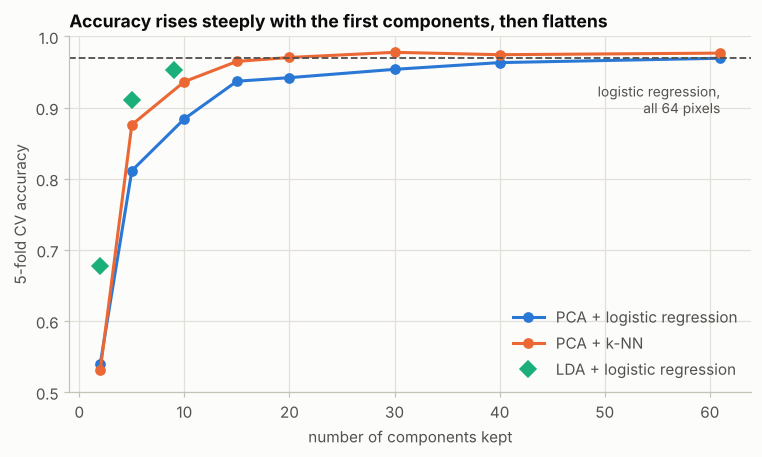

In [24]:
# EXTRA: (a) Accuracy against the number of components on the digits data (5-fold CV, reduction inside the pipeline)
from sklearn.linear_model import LogisticRegression

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
ks_pca = [2, 5, 10, 15, 20, 30, 40, 61]          # 61 = all non-constant directions of the 64 pixels
rows = []
for k in ks_pca:
    logreg_acc = cross_val_score(Pipeline([("scaler", StandardScaler()), ("pca", PCA(n_components=k)),
                                           ("clf", LogisticRegression(max_iter=2000))]),
                                 digits.data, digits.target, cv=cv5).mean()
    knn_acc = cross_val_score(Pipeline([("scaler", StandardScaler()), ("pca", PCA(n_components=k)),
                                        ("clf", KNeighborsClassifier())]),
                              digits.data, digits.target, cv=cv5).mean()
    rows.append(("PCA", k, logreg_acc, knn_acc))
for k in [2, 5, 9]:                               # LDA: at most 10 - 1 = 9 discriminants
    logreg_acc = cross_val_score(Pipeline([("scaler", StandardScaler()),
                                           ("lda", LinearDiscriminantAnalysis(n_components=k)),
                                           ("clf", LogisticRegression(max_iter=2000))]),
                                 digits.data, digits.target, cv=cv5).mean()
    rows.append(("LDA", k, logreg_acc, np.nan))
by_k = pd.DataFrame(rows, columns=["reduction", "components", "logistic regression", "k-NN"])
baseline = cross_val_score(Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=2000))]),
                           digits.data, digits.target, cv=cv5).mean()
display(by_k.round(4).set_index(["reduction", "components"]).T)
print(f"logistic regression on all 64 standardized pixels: {baseline:.4f}")

fig, ax = plt.subplots(figsize=(8, 4.2))
pca_rows = by_k[by_k["reduction"] == "PCA"]
lda_rows = by_k[by_k["reduction"] == "LDA"]
ax.plot(pca_rows["components"], pca_rows["logistic regression"], color=PALETTE[0], marker="o", markersize=6,
        label="PCA + logistic regression")
ax.plot(pca_rows["components"], pca_rows["k-NN"], color=PALETTE[1], marker="o", markersize=6, label="PCA + k-NN")
ax.plot(lda_rows["components"], lda_rows["logistic regression"], color=PALETTE[2], marker="D", markersize=7,
        linestyle="none", label="LDA + logistic regression")
ax.axhline(baseline, color=INK_SOFT, linestyle="--", linewidth=1.2)
ax.text(61, baseline - 0.035, "logistic regression,\nall 64 pixels", ha="right", va="top", fontsize=9, color=INK_SOFT)
ax.set(xlabel="number of components kept", ylabel="5-fold CV accuracy", ylim=(0.5, 1.0),
       title="Accuracy rises steeply with the first components, then flattens")
ax.legend(loc="lower right")
plt.show()

,5-fold CV accuracy
model,
"PCA, 1 component",0.535
"LDA, 1 discriminant",0.965
no reduction (2 features),0.965


correlation of the two features: 0.852
explained variance ratio of PC1, PC2: [0.926 0.074]
PC1 direction: [0.707 0.707] | LDA direction: [ 0.685 -0.729]


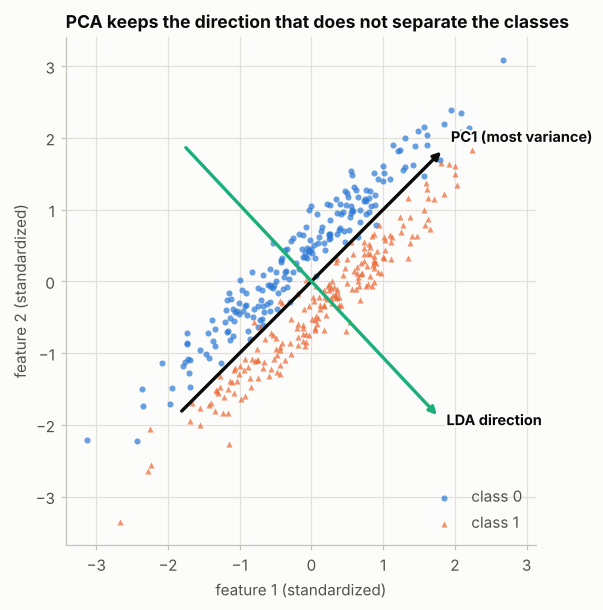

In [25]:
# EXTRA: (b) High variance is not the same as useful -- the class signal sits in a low-variance direction
rng = np.random.default_rng(1)
n = 400
y_toy = rng.integers(0, 2, size=n)
shared = rng.normal(0, 3, size=n)                       # large common factor, unrelated to the class
shift = np.where(y_toy == 1, 0.75, -0.75)               # the class moves the two features in opposite directions
X_toy = np.column_stack([shared + shift + rng.normal(0, 0.5, n),
                         shared - shift + rng.normal(0, 0.5, n)])

rows = []
for name, reducer in [("PCA, 1 component", PCA(n_components=1)),
                      ("LDA, 1 discriminant", LinearDiscriminantAnalysis(n_components=1)),
                      ("no reduction (2 features)", "passthrough")]:
    model = Pipeline([("scaler", StandardScaler()), ("reduce", reducer), ("clf", LogisticRegression())])
    rows.append((name, cross_val_score(model, X_toy, y_toy, cv=cv5).mean()))
display(pd.DataFrame(rows, columns=["model", "5-fold CV accuracy"]).set_index("model").round(3))

Z_toy = StandardScaler().fit_transform(X_toy)
pca_toy = PCA().fit(Z_toy)
lda_dir = LinearDiscriminantAnalysis().fit(Z_toy, y_toy).scalings_[:, 0]
lda_dir = lda_dir / np.linalg.norm(lda_dir)
print("correlation of the two features:", round(np.corrcoef(X_toy, rowvar=False)[0, 1], 3))
print("explained variance ratio of PC1, PC2:", pca_toy.explained_variance_ratio_.round(3))
print("PC1 direction:", pca_toy.components_[0].round(3), "| LDA direction:", lda_dir.round(3))

fig, ax = plt.subplots(figsize=(6.4, 6))
for cls, (color, marker) in enumerate(zip(PALETTE[:2], ["o", "^"])):
    m = y_toy == cls
    ax.scatter(Z_toy[m, 0], Z_toy[m, 1], s=16, color=color, marker=marker, alpha=0.7, linewidth=0, label=f"class {cls}")
for vec, name, color in [(pca_toy.components_[0], "PC1 (most variance)", INK), (lda_dir, "LDA direction", PALETTE[2])]:
    ax.annotate("", xy=tuple(2.6 * vec), xytext=tuple(-2.6 * vec),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2.2))
    ax.text(*(2.75 * vec), name, fontsize=9.5, color=INK, fontweight="bold",
            path_effects=[patheffects.withStroke(linewidth=3, foreground=SURFACE)])
ax.set(xlabel="feature 1 (standardized)", ylabel="feature 2 (standardized)", aspect="equal",
       title="PCA keeps the direction that does not separate the classes")
ax.legend(loc="lower right")
plt.show()

**Output analysis.**

* **(a) Accuracy against $k$:**
  * Two principal components give only about 54% accuracy on ten digits.
  * Ten components already reach about 88% (logistic regression) and 94% (k-NN).
  * From about 30 components on, both curves are within two points of the full model.
  * For k-NN, about 30 components are even marginally *better* than all 61 directions: the dropped low-variance directions are mostly noise, which hurts a distance-based model.
  * LDA's 9 discriminants reach about 95%: very compact, but below the best PCA settings, because 9 is the hard limit for 10 classes.

  This is the book's "training time vs. accuracy" trade-off in numbers: half of the dimensions buys almost all of the accuracy.
* **(b) Variance is not relevance:**
  * The two features are strongly correlated, and PC1 — their sum, with about 93% of the variance — carries no class information: one component gives coin-flip accuracy.
  * The LDA direction is essentially the difference of the features (PC2, the low-variance direction), and with it 96.5% of the points are classified correctly. With both features and no reduction, logistic regression does just as well.

  An unsupervised reduction is only safe when the signal lives in the high-variance directions, so always compare the reduced and the full model (the book's step 4 of recipe 1).

---
## 7. Practical exercises in dimensionality reduction

### Summary

* The chapter closes with two exercises that apply the techniques to datasets and show when and how each one helps.
* **Example 1: PCA with logistic regression.**
  * The text says the exercise analyses how PCA before a logistic regression affects performance on the **Iris** dataset. Logistic regression has not been covered yet, so this is an exercise in "pushing your boundaries".
  * Steps: load the libraries, split the data, build a pipeline without PCA and one with PCA, fit and evaluate both, print the results.
* **Example 2: t-SNE for visualization.**
  * The exercise uses t-SNE on a more complex dataset ("e.g., MNIST") while analysing how it relates to classification.
  * Steps: load the libraries, apply K-means clustering, create side-by-side plots, and colour the same t-SNE map once by the true labels and once by the cluster labels.
* **Closing:** dimensionality reduction can simplify data and improve interpretability while potentially sacrificing some accuracy, and understanding these trade-offs is essential. The next chapter moves to model training.

> The book lists only the steps. The code below is the **official solution** from the chapter's exercise notebook in the book's repository. That solution runs Example 1 on the digits data instead of Iris; the extras run both.

### Theory: the tools used in the exercises

* **`PCA(n_components=0.95)`.** A float between 0 and 1 asks PCA to keep the smallest number of components whose cumulative explained variance exceeds that fraction. The chosen number is stored in `n_components_`.
* **One split is a noisy judge.** An accuracy $a$ measured on $m$ test samples has a standard error of about $\sqrt{a(1-a)/m}$:
  * for the digits ($a \approx 0.97$, $m = 360$) that is about 0.9 percentage points;
  * for Iris ($m = 30$) it is about 4.7 points.

  Differences of that size between two pipelines can be luck. Repeated cross-validation gives a fairer comparison (Chapter 12).
* **K-means** (Chapter 10) splits the data into $k$ groups by minimizing the within-cluster sum of squared distances to the cluster centres. Its cluster numbers are arbitrary: cluster 3 need not contain the digit 3, so colours cannot be compared between the two panels of Example 2.
* **The adjusted Rand index (ARI)** (Hubert & Arabie, 1985) compares two partitions while ignoring how the groups are numbered:

$$\mathrm{ARI} = \frac{\mathrm{RI} - \mathbb{E}[\mathrm{RI}]}{\max(\mathrm{RI}) - \mathbb{E}[\mathrm{RI}]},$$

  where RI is the share of pairs of points on which the two partitions agree (same group in both, or different groups in both). ARI is 1 for identical partitions and about 0 for a random one.

In [26]:
# BOOK CODE: Example 1 -- PCA with logistic regression (p. 67; official solution from the book's repository)
# Load libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=2024
)

# Pipeline without PCA
pipeline_no_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])

# Pipeline with PCA
pipeline_with_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),  # Keep 95% of variance
    ('clf', LogisticRegression(max_iter=1000))
])

# Fit and evaluate both pipelines
pipeline_no_pca.fit(X_train, y_train)
pipeline_with_pca.fit(X_train, y_train)

# Print results
print("Accuracy without PCA:",
      accuracy_score(y_test, pipeline_no_pca.predict(X_test)))
print("Accuracy with PCA:",
      accuracy_score(y_test, pipeline_with_pca.predict(X_test)))

Accuracy without PCA: 0.975
Accuracy with PCA: 0.9638888888888889


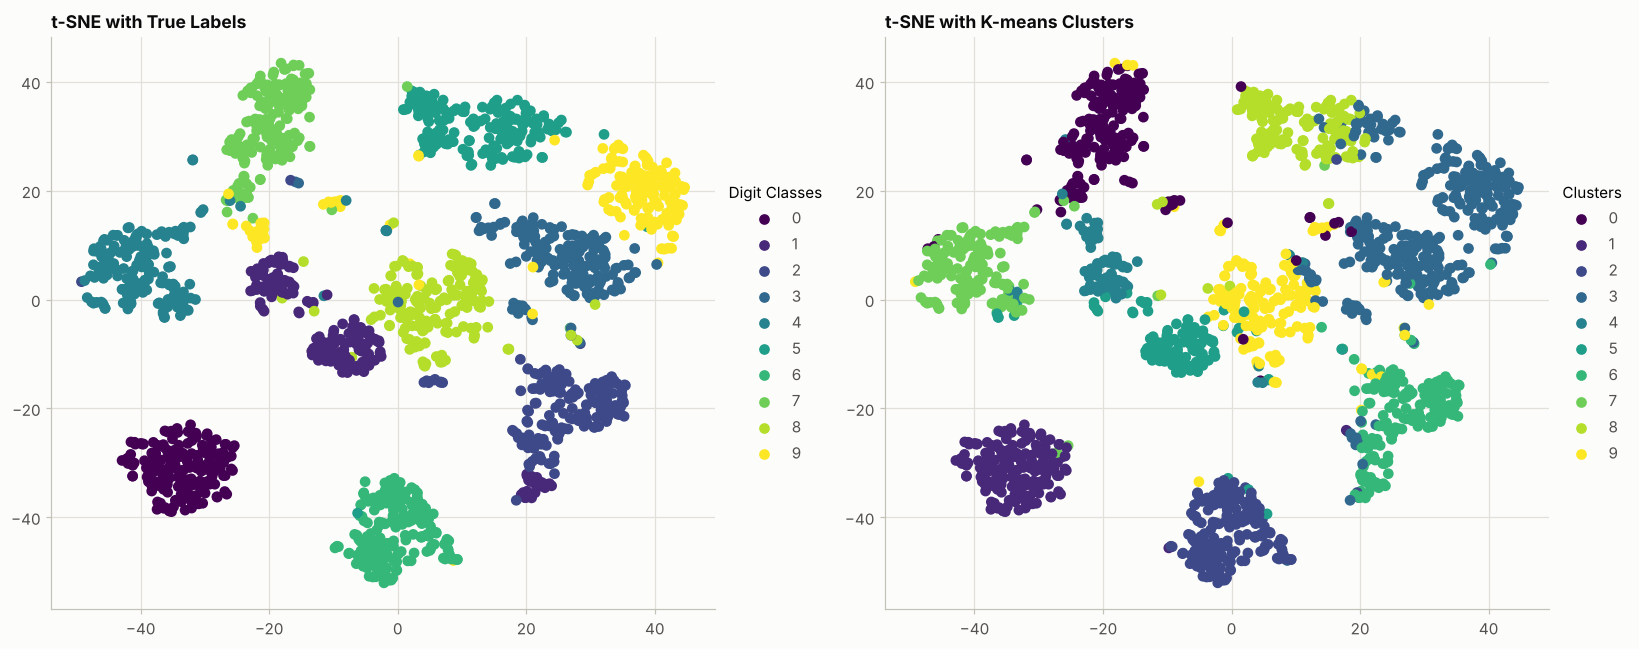

In [27]:
# BOOK CODE: Example 2 -- t-SNE for clustering visualization (p. 67; official solution from the book's repository)
# Load libraries
from sklearn.cluster import KMeans

# Apply K-means clustering
kmeans = KMeans(n_clusters=10, random_state=2024)
cluster_labels = kmeans.fit_predict(digits.data)

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot using true labels
scatter1 = ax1.scatter(X_tsne[:, 0], X_tsne[:, 1],
                      c=digits.target, cmap='viridis')
ax1.set_title('t-SNE with True Labels')
legend1 = ax1.legend(*scatter1.legend_elements(),
                    title="Digit Classes",
                    loc="center left",
                    bbox_to_anchor=(1, 0.5))

# Plot using cluster labels
scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1],
                      c=cluster_labels, cmap='viridis')
ax2.set_title('t-SNE with K-means Clusters')
legend2 = ax2.legend(*scatter2.legend_elements(),
                    title="Clusters",
                    loc="center left",
                    bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

**Output analysis.**

* **Example 1.** On the 360 held-out digits, logistic regression scores 0.975 without PCA and about 0.964 with it. `PCA(n_components=0.95)` kept 39 of the 64 directions (printed in the extra below). Losing about one point of accuracy for 40% fewer inputs is the trade-off of recipe 6. The difference is about one standard error, though, so a single split cannot tell whether it is real (extra a).
* **Example 2:**
  * The left panel colours the t-SNE map by the true digits; the right panel colours the *same* map by the K-means clusters, computed on the raw pixels.
  * Many clusters coincide with digit groups, but some groups are split between two clusters and some clusters merge parts of two digits.
  * The colours of the two panels cannot be matched one to one, because cluster numbers are arbitrary.
  * The exercise text promises to analyse the impact "on subsequent classification tasks", but the solution only compares pictures. Extra (b) puts a number on the agreement.

In [28]:
# EXTRA: (a) Example 1 as the text describes it (Iris) and as the solution runs it (digits), with 10-fold CV
from sklearn.datasets import load_iris

iris = load_iris()
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
rows = []
for name, X_ex, y_ex in [("digits", digits.data, digits.target), ("Iris", iris.data, iris.target)]:
    X_tr, X_te, y_tr, y_te = train_test_split(X_ex, y_ex, test_size=0.2, random_state=2024)
    without = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=1000))])
    with_pca = Pipeline([("scaler", StandardScaler()), ("pca", PCA(n_components=0.95)),
                         ("clf", LogisticRegression(max_iter=1000))])
    kept = with_pca.fit(X_tr, y_tr).named_steps["pca"].n_components_
    split_without = without.fit(X_tr, y_tr).score(X_te, y_te)
    split_with = with_pca.score(X_te, y_te)
    cv_without = cross_val_score(without, X_ex, y_ex, cv=cv10)
    cv_with = cross_val_score(with_pca, X_ex, y_ex, cv=cv10)
    rows.append((name, X_ex.shape[1], kept, split_without, split_with,
                 f"{cv_without.mean():.3f} +/- {cv_without.std():.3f}", f"{cv_with.mean():.3f} +/- {cv_with.std():.3f}"))
display(pd.DataFrame(rows, columns=["dataset", "features", "components for 95%", "split: without PCA",
                                    "split: with PCA", "10-fold CV: without PCA", "10-fold CV: with PCA"])
        .set_index("dataset").round(3))

,features,components for 95%,split: without PCA,split: with PCA,10-fold CV: without PCA,10-fold CV: with PCA
dataset,,,,,,
digits,64,39,0.975,0.964,0.967 +/- 0.012,0.963 +/- 0.015
Iris,4,2,0.933,0.833,0.953 +/- 0.043,0.913 +/- 0.060


In [29]:
# EXTRA: (b) Example 2 in numbers -- how well do K-means clusters match the digits? (adjusted Rand index)
from sklearn.metrics import adjusted_rand_score

clusterings = {
    "K-means on the raw pixels (the official solution)": cluster_labels,
    "K-means on standardized pixels": KMeans(n_clusters=10, random_state=2024).fit_predict(X_digits_std),
    "K-means on the 2-D t-SNE map": KMeans(n_clusters=10, random_state=2024).fit_predict(X_tsne),
}
display(pd.Series({name: adjusted_rand_score(digits.target, labels) for name, labels in clusterings.items()},
                  name="ARI with the true digits").round(3).to_frame())
contingency = pd.crosstab(pd.Series(digits.target, name="digit"), pd.Series(cluster_labels, name="cluster"))
print("raw-pixel clusters: share of each digit that falls in its most common cluster")
print((contingency.max(axis=1) / contingency.sum(axis=1)).round(2).to_string())

,ARI with the true digits
K-means on the raw pixels (the official solution),0.657
K-means on standardized pixels,0.491
K-means on the 2-D t-SNE map,0.867


raw-pixel clusters: share of each digit that falls in its most common cluster
digit
0    0.99
1    0.55
2    0.84
3    0.88
4    0.90
5    0.76
6    0.97
7    0.97
8    0.78
9    0.81


**Output analysis.**

* **(a) Iris versus digits:**
  * On Iris, 95% of the variance needs only 2 components for the 4 standardized features.
  * There, PCA costs accuracy both on the single split (0.933 vs. 0.833) and in 10-fold cross-validation (about 0.95 vs. 0.91). Iris has so few features that dropping two of them removes real information.
  * On the digits, PCA keeps 39 components, and the cross-validated accuracies differ by less than their spread across folds: no meaningful loss.

  So the answer to "does PCA help?" depends on the data, which is exactly why the book recommends comparing the original and the reduced data. The text and the official solution use different datasets; the conclusions differ too.
* **(b) Clusters versus digits:**
  * K-means on the raw pixels agrees with the true digits with an ARI of about 0.66: clearly better than chance, far from perfect.
  * Standardizing the pixels makes it *worse* (about 0.49). Rare border pixels, almost always 0, get the same weight as the informative centre pixels.
  * K-means on the t-SNE map agrees much better (about 0.87), because t-SNE has already pulled each digit's neighbourhood together.
  * The per-digit table shows where K-means fails: the 1s are split almost in half (55% in their main cluster) — the same digit that forms three islands on the t-SNE map — while 0s, 6s and 7s each sit almost entirely in one cluster.

  Clustering a t-SNE map works here because the digit groups are well separated, but it remains risky in general: t-SNE distorts densities and distances, and the map cannot place new points. Treat it as exploration, not as a model.

---
## Decision guide: choosing a dimensionality reduction technique

This table is a text version of the book's flowchart (Figure 3.8), extended with the other tools mentioned in recipe 5.

| Situation | Technique | Why |
|---|---|---|
| Labelled data, goal is classification | `LinearDiscriminantAnalysis` (or a supervised selector from Chapter 2) | maximizes class separation; at most $C - 1$ components; fit it inside cross-validation |
| No labels, need fewer features for a model, compression or denoising | `PCA` after `StandardScaler` | keeps the most variance, has `transform`, fast |
| Sparse, high-dimensional data such as text | `TruncatedSVD` | no centring, accepts sparse input |
| Need a 2-D or 3-D picture of cluster structure | `TSNE`, often after `PCA` to 30–50 components | preserves local neighbourhoods; for visualization only |
| Non-linear structure, but new data must be transformed | `KernelPCA`, `Isomap` | non-linear, with `transform` |
| The original features must stay interpretable | feature selection (`SelectKBest`, `RFE`, `SelectFromModel`) | keeps the original columns |

## Chapter summary and key takeaways

| Recipe | Main tools | Key idea |
|---|---|---|
| Introduction | — | High dimensions make data sparse and distances uninformative; real data usually have a lower intrinsic dimension |
| PCA | `PCA`, `StandardScaler` | Eigenvectors of the covariance matrix; keep the components with the largest eigenvalues; scale first |
| LDA | `LinearDiscriminantAnalysis` | Maximize between-class over within-class scatter; at most $C - 1$ components; supervised, so validate on held-out data |
| t-SNE | `TSNE`, `trustworthiness` | Match neighbourhood probabilities with a heavy-tailed map; local structure only; no `transform` |
| Selecting a technique | Table 3.1, Figure 3.8 | Labels, goal (features or pictures), cost and interpretability decide |
| Impact on performance | `GridSearchCV` over `n_components` | A few components often keep most of the accuracy, but high variance is not the same as relevance |
| Practical exercises | `PCA(n_components=0.95)`, `KMeans`, `adjusted_rand_score` | Compare reduced and full models with cross-validation; quantify cluster agreement instead of eyeballing colours |

**Key takeaways**

1. Dimensionality reduction fights the curse of dimensionality, but it removes information too: always compare the reduced model with the full one.
2. PCA is an eigenproblem on the covariance matrix. Standardize first, read `explained_variance_ratio_`, and choose the number of components with the downstream model.
3. LDA uses the labels, so it can separate classes in ways PCA cannot — and it can also "separate" random labels on training data. Fit it inside cross-validation.
4. t-SNE is for looking, not for modelling. Trust its neighbourhoods, not its distances or cluster sizes, and try more than one perplexity.
5. Unsupervised reduction keeps variance, not relevance: the signal can hide in a low-variance direction.

**Book (scikit-learn 1.5) vs. the version used here — notes from the reproduction**

* All listings and both official exercise solutions run unchanged on scikit-learn 1.9.1. The printed value of the PCA recipe is reproduced: the first two components explain 55.41% of the variance. The t-SNE map shows the features the book describes for Figure 3.7: an isolated group of 0s in the bottom-left corner, and 9s near the 7s and 4s.
* `TSNE`'s `n_iter` parameter was renamed `max_iter` in scikit-learn 1.5, and `PCA` gained the `"covariance_eigh"` solver in 1.5. The book's code uses neither, so it is unaffected.
* Small precisions to the chapter text:
  * The arrows of the PCA plot are the weights of alcohol and malic acid on each component, not the components' directions.
  * PCA of two standardized features to two components is a 45° rotation, so it cannot improve class separation (Figure 3.4).
  * The first two principal components capture more variance than any other pair of directions, but here only 55% of the total.
  * LDA's "common covariance matrix" means that all classes share one covariance matrix. Standardization does not make this hold, and LDA's projection does not change with scaling.
  * PCA components and LDA discriminants are both linear combinations of all features; neither is inherently more interpretable.
  * The digits dataset is the UCI optical digits data ($8 \times 8$ images), not MNIST. t-SNE does not use the labels, so it reveals neighbourhoods rather than "excelling at class separation".
  * Example 1 is described on Iris but solved on the digits.

## References

1. Sukup, J. (2025). *scikit-learn Cookbook* (3rd ed.). Packt Publishing. Code repository: <https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition>
2. Pearson, K. (1901). On lines and planes of closest fit to systems of points in space. *The London, Edinburgh, and Dublin Philosophical Magazine and Journal of Science, 2*(11), 559–572.
3. Hotelling, H. (1933). Analysis of a complex of statistical variables into principal components. *Journal of Educational Psychology, 24*(6), 417–441.
4. Jolliffe, I. T., & Cadima, J. (2016). Principal component analysis: a review and recent developments. *Philosophical Transactions of the Royal Society A, 374*(2065), 20150202.
5. Fisher, R. A. (1936). The use of multiple measurements in taxonomic problems. *Annals of Eugenics, 7*(2), 179–188.
6. Ledoit, O., & Wolf, M. (2004). A well-conditioned estimator for large-dimensional covariance matrices. *Journal of Multivariate Analysis, 88*(2), 365–411.
7. van der Maaten, L., & Hinton, G. (2008). Visualizing data using t-SNE. *Journal of Machine Learning Research, 9*, 2579–2605.
8. van der Maaten, L. (2014). Accelerating t-SNE using tree-based algorithms. *Journal of Machine Learning Research, 15*, 3221–3245.
9. Wattenberg, M., Viégas, F., & Johnson, I. (2016). How to use t-SNE effectively. *Distill*. <https://distill.pub/2016/misread-tsne/>
10. Kobak, D., & Berens, P. (2019). The art of using t-SNE for single-cell transcriptomics. *Nature Communications, 10*, 5416.
11. Venna, J., & Kaski, S. (2001). Neighborhood preservation in nonlinear projection methods: an experimental study. In *Artificial Neural Networks — ICANN 2001* (pp. 485–491). Springer.
12. Beyer, K., Goldstein, J., Ramakrishnan, R., & Shaft, U. (1999). When is "nearest neighbor" meaningful? In *Database Theory — ICDT'99* (pp. 217–235). Springer.
13. Hubert, L., & Arabie, P. (1985). Comparing partitions. *Journal of Classification, 2*(1), 193–218.
14. LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. *Proceedings of the IEEE, 86*(11), 2278–2324.
15. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.
16. scikit-learn documentation: [Decomposing signals in components (PCA)](https://scikit-learn.org/stable/modules/decomposition.html) · [Linear and quadratic discriminant analysis](https://scikit-learn.org/stable/modules/lda_qda.html) · [Manifold learning (t-SNE)](https://scikit-learn.org/stable/modules/manifold.html) · [Optical recognition of handwritten digits dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#optical-recognition-of-handwritten-digits-dataset) · [Clustering performance evaluation](https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation)